# Gibbs sampling + FFBS + Marginal likelihood (bridge sampling)

This notebook replaces the original HMC/NUTS (NumPyro) implementation with **Gibbs samplers written from scratch**.

- **Regression-only models** use conjugate Gaussian / inverse-gamma updates.
- **State-space joint decomposition models** use **FFBS (Forward-Filtering Backward-Sampling)** for the latent states.
- Model comparison is performed via **(log) marginal likelihood** using a **bridge sampling** estimator (implemented from scratch).

In [ ]:
import numpy as np
import pandas as pd

from scipy.special import logsumexp, gammaln
from scipy.stats import gaussian_kde, norm
from tqdm.auto import tqdm


from IPython.display import display, HTML

# plotting (optional)
import matplotlib.pyplot as plt

# -----------------------------
# Global numeric helpers
# -----------------------------
_EPS = 1e-12


try:
    from scipy.interpolate import PchipInterpolator
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


# ---- helper functions ----
def to_datetime(s, fmt=None):
    return pd.to_datetime(s, format=fmt) if fmt else pd.to_datetime(s)

def yoy_pct(series_q):
    # Exact YoY percent change: 100*(x/lag4 - 1)
    return 100 * (series_q / series_q.shift(4) - 1)

def log_yoy(series_q):
    # Log-difference YoY ×100
    return 100 * (np.log(series_q) - np.log(series_q).shift(4))

def resample_quarterly_mean(df, date_col, value_cols):
    x = df.copy()
    x[date_col] = to_datetime(x[date_col])
    x = x.set_index(date_col).sort_index()
    q = x.resample("Q").mean()  # quarterly mean
    q.index.freq = "Q"
    return q[value_cols]

def annual_to_quarterly_pchip(df, date_col, value_col):
    """
    Convert annual data to quarterly using PCHIP interpolation.
    Falls back to time/polynomial interpolation if scipy unavailable.
    """
    x = df[[date_col, value_col]].copy()
    x[date_col] = to_datetime(x[date_col])
    x = x.set_index(date_col).sort_index()

    a = x.asfreq("YS")
    q_index = pd.date_range(a.index.min(), a.index.max(), freq="Q")
    q = pd.DataFrame(index=q_index, data=np.nan, columns=[value_col])
    q.index.freq = "Q"
    merged = a.reindex(a.index.union(q.index)).sort_index()

    if _HAS_SCIPY:
        xi = merged.index.view("i8")
        mask = merged[value_col].notna().values
        xx = xi[mask].astype(float)
        yy = merged.loc[mask, value_col].astype(float).values
        if len(xx) >= 2:
            f = PchipInterpolator(xx, yy)
            merged[value_col] = pd.Series(f(xi.astype(float)), index=merged.index)
        else:
            merged[value_col] = merged[value_col].interpolate(method="time")
    else:
        try:
            merged[value_col] = merged[value_col].interpolate(method="time")
            merged[value_col] = merged[value_col].interpolate(method="polynomial", order=3)
        except Exception:
            merged[value_col] = merged[value_col].interpolate()

    return merged.reindex(q_index)

# ---- SPF (xlsx) ----
spf = pd.read_excel("../data/inflation/Inflation.xlsx")
q_month = (spf["QUARTER"] * 3)
spf["DATE"] = pd.to_datetime(
    spf["YEAR"].astype(str) + "-" + q_month.astype(str) + "-01"
) + pd.offsets.MonthEnd(0)
spf["Epi_spf_gdp"] = spf["INFPGDP1YR"]
spf["Epi_spf_cpi"] = spf["INFCPI1YR"]
tt_spf = spf[["DATE", "Epi_spf_gdp", "Epi_spf_cpi"]].set_index("DATE").sort_index()
tt_spf.index = tt_spf.index.to_period("Q").to_timestamp(how="end")
tt_spf.index.freq = "Q"

# ---- PPI -----------------------
ppi = pd.read_csv("../data/inflation/PPIACO.csv")
date_col = "DATE" if "DATE" in ppi.columns else ("observation_date" if "observation_date" in ppi.columns else None)
if date_col is None:
    raise ValueError("PPIACO.csv must have DATE or observation_date column.")
tt_ppi_m = ppi[[date_col, "PPIACO"]].copy()
tt_ppi_q = resample_quarterly_mean(ppi, date_col, ["PPIACO"])
tt_ppi_q["pi_ppi"] = yoy_pct(tt_ppi_q["PPIACO"])
tt_ppi_q = tt_ppi_q[["pi_ppi"]]


# ---- CPI headline (monthly → quarterly → YoY%) ----
cpi = pd.read_csv("../data/inflation/CPIAUCSL.csv")
date_col = "DATE" if "DATE" in cpi.columns else ("observation_date" if "observation_date" in cpi.columns else None)
if date_col is None:
    raise ValueError("CPIAUCSL.csv must have DATE or observation_date column.")
tt_cpi_q = resample_quarterly_mean(cpi, date_col, ["CPIAUCSL"])
tt_cpi_q["pi_cpi"] = yoy_pct(tt_cpi_q["CPIAUCSL"])
tt_cpi_q = tt_cpi_q[["pi_cpi"]]

# ---- Core CPI (log YoY) ----
core = pd.read_csv("../data/inflation/CPILFESL.csv")
date_col = "DATE" if "DATE" in core.columns else ("observation_date" if "observation_date" in core.columns else None)
if date_col is None:
    raise ValueError("CPILFESL.csv must have DATE or observation_date column.")
tt_core_m = core[[date_col, "CPILFESL"]].copy()
tt_core_m[date_col] = to_datetime(tt_core_m[date_col])
tt_core_q = tt_core_m.set_index(date_col).sort_index().resample("Q").mean()
tt_core_q.index.freq = "Q"
tt_core_q["pi_cpi_core"] = log_yoy(tt_core_q["CPILFESL"])
tt_core = tt_core_q[["pi_cpi_core"]]

# ---- PCE headline (log YoY) ----
pce = pd.read_csv("../data/inflation/PCEPI.csv")
date_col = "DATE" if "DATE" in pce.columns else ("observation_date" if "observation_date" in pce.columns else None)
tt_pce_m = pce[[date_col, "PCEPI"]].copy()
tt_pce_m[date_col] = to_datetime(tt_pce_m[date_col])
tt_pce_q = tt_pce_m.set_index(date_col).sort_index().resample("Q").mean()
tt_pce_q.index.freq = "Q"
tt_pce_q["pi_pce"] = log_yoy(tt_pce_q["PCEPI"])
tt_pce = tt_pce_q[["pi_pce"]]

# ---- PCE core (log YoY) ----
pce_core = pd.read_csv("../data/inflation/PCEPILFE.csv")
date_col = "DATE" if "DATE" in pce_core.columns else ("observation_date" if "observation_date" in pce_core.columns else None)
tt_pce_core_m = pce_core[[date_col, "PCEPILFE"]].copy()
tt_pce_core_m[date_col] = to_datetime(tt_pce_core_m[date_col])
tt_pce_core_q = tt_pce_core_m.set_index(date_col).sort_index().resample("Q").mean()
tt_pce_core_q.index.freq = "Q"
tt_pce_core_q["pi_pce_core"] = log_yoy(tt_pce_core_q["PCEPILFE"])
tt_pce_core = tt_pce_core_q[["pi_pce_core"]]

# ---- N (annual → quarterly, cubic interp) ----
hhi = pd.read_csv("../data/competition/BN_N_26.csv")
hhi["N"] = hhi["original_series"]
hhi["year"] = pd.to_datetime(pd.to_datetime(hhi["date"]).dt.year.astype(str) + "-01-01")
tt_hhi_q = annual_to_quarterly_pchip(hhi.rename(columns={"year": "DATE"}), "DATE", "N")
# ---- N cycle and trend (annual → quarterly, cubic interp) ----
nb = pd.read_csv("../data/competition/BN_N_26.csv")
nb["N_BN_cycle"] = nb["cycle"]
nb["N_BN_trend"] = nb["trend"]
nb["DATE"] = pd.to_datetime(pd.to_datetime(nb["date"]).dt.year.astype(str) + "-01-01")
nb = nb[["DATE", "N_BN_cycle","N_BN_trend"]].dropna()
tt_nb_q = annual_to_quarterly_pchip(nb, "DATE", "N_BN_cycle")
tt_nb_trend_q = annual_to_quarterly_pchip(nb, "DATE", "N_BN_trend")

# ---- Markup levels ----
mk = pd.read_excel("../data/markup/nekarda_ramey_markups.xlsx")
mk["DATE"] = to_datetime(mk["qdate"])
mk["markup"] = mk["mu_bus"]
tt_mk = mk[["DATE", "markup"]].dropna().set_index("DATE").sort_index()
tt_mk.index = tt_mk.index.to_period("Q").to_timestamp(how="end")
tt_mk.index.freq = "Q"

# ---- BN inverse markup ----
mk_bn = pd.read_csv("../data/markup/BN_markup_inv.csv")
mk_bn["markup_BN_inv"] = mk_bn["cycle"]
mk_bn["DATE"] = to_datetime(mk_bn["date"])
tt_mk_bn = mk_bn[["DATE", "markup_BN_inv"]].dropna().set_index("DATE").sort_index()
tt_mk_bn.index = tt_mk_bn.index.to_period("Q").to_timestamp(how="end")
tt_mk_bn.index.freq = "Q"

# ---- Employment gap (NROU - UNRATENSA) ----
nairu = pd.read_csv("../data/unemp_gap/NROU.csv")
unemp = pd.read_csv("../data/unemp_gap/UNRATENSA.csv")

dc1 = "DATE" if "DATE" in nairu.columns else "observation_date"
dc2 = "DATE" if "DATE" in unemp.columns else "observation_date"

# Make sure both DATE columns are real datetimes (on both sides!)
n = nairu[[dc1, "NROU"]].rename(columns={dc1: "DATE"})
u = unemp[[dc2, "UNRATENSA"]].rename(columns={dc2: "DATE"})
n["DATE"] = pd.to_datetime(n["DATE"], errors="coerce")
u["DATE"] = pd.to_datetime(u["DATE"], errors="coerce")

tt_gap = (
    n.merge(u, on="DATE", how="outer")
     .set_index("DATE")
     .sort_index()
     .resample("Q").mean()
)
tt_gap.index.freq = "Q"
tt_gap["unemp_gap"] = tt_gap["NROU"] - tt_gap["UNRATENSA"]
tt_gap = tt_gap[["unemp_gap"]].dropna()

# ---- Output gap data (BN filter) ----
out = pd.read_csv("../data/output_gap/BN_filter_GDPC1_quaterly.csv")
out["output_BN"] = out["GDPC1_transformed_series"]
out["output_gap_BN"] = out["cycle"]
out["output"] = np.log(out["GDPC1_original_series"] * 0.01)
out["DATE"] = to_datetime(out["date"])
out["output_trend_BN"] = out["output_BN"] - out["output_gap_BN"]
tt_out = (
    out[["DATE", "output_BN", "output_gap_BN", "output_trend_BN", "output"]]
    .dropna()
    .set_index("DATE")
    .sort_index()
)
tt_out.index = tt_out.index.to_period("Q").to_timestamp(how="end")
tt_out.index.freq = "Q"

# ---- Oil prices (WTI deflated by CPI, log YoY) ----
oil = pd.read_csv("../data/others/WTISPLC_CPIAUCSL.csv")
dc = "DATE" if "DATE" in oil.columns else "observation_date"
tt_oil = oil[[dc, "WTISPLC_CPIAUCSL"]].copy()
tt_oil[dc] = to_datetime(tt_oil[dc])
tt_oil = tt_oil.set_index(dc).sort_index().resample("Q").mean()
tt_oil.index.freq = "Q"
tt_oil["log_oil"] = np.log(tt_oil["WTISPLC_CPIAUCSL"])
tt_oil["oil"] = tt_oil["log_oil"] - tt_oil["log_oil"].shift(4)
tt_oil = tt_oil[["oil"]]

# ---- Inflation expectations (monthly → quarterly mean ×100) ----
epi = pd.read_csv("../data/inflation/one_year_inflation_expectation.csv")
epi["DATE"] = to_datetime(epi["Date"], fmt="%Y-%m-%d")
epi.astype({"DATE": str}).set_index("DATE", inplace=True)
epi["Epi"] = epi[" Epi"] * 100
epi = epi[["DATE","Epi"]]
tt_epi_m = pd.DataFrame({"DATE": epi["DATE"], "Epi": epi["Epi"]}).set_index("DATE").sort_index()
tt_epi = tt_epi_m.resample("Q").mean()

def as_qe_midnight(df):
    """Force index to quarter-end at 00:00:00 (no nanoseconds)."""
    out = df.copy()
    # ensure datetime index
    out.index = pd.to_datetime(out.index)
    # convert to quarter periods then back to Timestamps at end-of-quarter
    out.index = pd.PeriodIndex(out.index, freq="Q").to_timestamp(how="end").normalize()
    out.index.name = "DATE"
    # freq is not needed; leave it unset to avoid surprises
    out.index.freq = None
    return out
dfs = [
    tt_cpi_q, tt_epi, tt_spf, tt_core, tt_out, tt_hhi_q, tt_nb_q,tt_nb_trend_q,
    tt_mk, tt_pce_core, tt_pce, tt_mk_bn, tt_gap, tt_oil, tt_ppi_q
]
dfs = [as_qe_midnight(d) for d in dfs] 
data = pd.concat(dfs, axis=1).sort_index()

data.index = data.index.to_period("Q").to_timestamp(how="end")
data.index.freq = "Q"

# ---- Add lagged variables ----
for col in ["pi_ppi","pi_cpi", "pi_cpi_core", "pi_pce", "pi_pce_core", "N_BN_trend"]:
    if col in data.columns:
        data[f"{col}_prev"] = data[col].shift(1)

    

data = data.loc["1982-01-01":"2012-12-31"]
data['DATE'] = pd.to_datetime(data.index)

pi = np.asarray(data['pi_cpi'], dtype=float)
pi_prev = np.asarray(data['pi_cpi_prev'], dtype=float)
pi_expect = np.asarray(data['Epi_spf_cpi'], dtype=float)

N = np.asarray(data['N'], dtype=float)
Nbar = np.asarray(data['N_BN_trend'], dtype=float)
Nhat = np.asarray(data['N_BN_cycle'], dtype=float)

# candidate x series
x_employment_gap = np.asarray(data['unemp_gap'], dtype=float)
x_markup = np.asarray(data["markup_BN_inv"], dtype=float)
x_output_gap = np.asarray(data["output_gap_BN"], dtype=float)

T = len(pi)
assert len(pi_prev)==T and len(pi_expect)==T and len(N)==T and len(Nbar)==T and len(Nhat)==T

# --- 2×2 graph ---
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. Inflation and Expected Inflation ---
ax1= axs[0, 0]
ax1_left = ax1
ax1_left.plot(data["DATE"], data["pi_ppi"], label=r'PPI', color='orange')
ax1_left.plot(data["DATE"], data["pi_cpi"], label=r'CPI', color='blue')
ax1_left.plot(data["DATE"], data["Epi_spf_cpi"], label=r'Epi: SPF$', linestyle='-.', color='green')
ax1_left.plot(data["DATE"], data["Epi"], label=r'Epi: Crev FED$', linestyle='-.', color='red')
ax1_left.set_xlabel('Year', fontsize=12, weight='bold')
ax1_left.set_ylabel('Inflation Rate', fontsize=12, weight='bold', color = 'black')
ax1_left.grid(True, linestyle='--', alpha=0.6)
ax1_left.set_title('One Year Inflation Rate and Expectations', fontsize=14)
lines = ax1_left.get_lines()
labels = [line.get_label() for line in lines]
ax1_left.legend(lines, labels, loc='upper right', fontsize=8)

# --- 2. Number of Firms and Markup ---
ax2 = axs[0, 1]
ax2_left = ax2
ax2_right = ax2_left.twinx()
ax2_left.plot(data["DATE"], data["N"], label=r'N', color='blue')
ax2_right.plot(data["DATE"], data["markup"], label=r'Markup $(\mu_{t})$', linestyle='-.', color='green')
ax2_left.set_xlabel('Year', fontsize=12, weight='bold')
ax2_left.set_ylabel('N: Inverse of HHI', fontsize=12, weight='bold', color = 'blue')
ax2_right.set_ylabel('Markup', fontsize=12, weight='bold', color='green')
ax2_right.tick_params(axis='y', labelcolor='green')
ax2_left.grid(True, linestyle='--', alpha=0.6)
ax2_left.set_title('Number of Firms and Markup', fontsize=14)
lines = ax2_left.get_lines() + ax2_right.get_lines()
labels = [line.get_label() for line in lines]
ax2_left.legend(lines, labels, loc='upper left', fontsize=8)

# --- 3.  Number of Firms: trend / cycle ---
ax3 = axs[1, 0]
ax3_left = ax3
ax3_right = ax3_left.twinx()
ax3_left.plot(data["DATE"], data["N"], label='N', color='black')
ax3_left.plot(data["DATE"], data["N_BN_trend"], label='trend', color='blue')
ax3_right.plot(data["DATE"],data["N_BN_cycle"], label=r'cycle', linestyle='-.', color='green')
ax3_left.set_xlabel('Year', fontsize=12, weight='bold')
ax3_left.set_ylabel('N: Inverse of HHI', fontsize=12, weight='bold')
ax3_right.set_ylabel('cycle', fontsize=12, weight='bold', color='green')
ax3_right.tick_params(axis='y', labelcolor='green')
ax3_left.grid(True, linestyle='--', alpha=0.6)
ax3_left.set_title('Number of Firms: trend / cycle ', fontsize=14)
lines = ax3_left.get_lines() + ax3_right.get_lines()
labels = [line.get_label() for line in lines]
ax3_left.legend(lines, labels, loc='upper left', fontsize=8)

# --- 5. Output Gaps ------
ax5 = axs[1, 1]
ax5_left = ax5
ax5_right = ax5_left.twinx()
ax5_left.set_ylabel('Output gap', fontsize=12, weight='bold', color='black')
ax5_left.plot(data["DATE"], data["output_gap_BN"], label=r'GDPC1 (BN)', color='black')
ax5_right.plot(data["DATE"], data["unemp_gap"], label=r'Employment Gap', color='blue')
ax5_right.plot(data["DATE"], data["markup_BN_inv"], label=r'Markup inv (BN)', color='green')
ax5_left.set_title('Output Gap', fontsize=14)
ax5_left.set_xlabel('Year', fontsize=12, weight='bold')
lines = ax5_left.get_lines() + ax5_right.get_lines()
labels = [line.get_label() for line in lines]
ax5_left.legend(lines, labels, loc='lower right', fontsize=8)
# --- Layout ---
plt.tight_layout()
plt.show()

/opt/homebrew/Caskroom/miniforge/base/envs/bayes-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ============================================================
# Prior hyperparameters (same locations/scales as your HMC code)
# ============================================================

alpha_mu   = 0.5
alpha_sd   = 0.2

kappa_mu   = 0.1
kappa_sd   = 0.2

theta_mu   = 0.1
theta_sd   = 0.2

delta_mu   = 0.1
delta_sd   = 0.2

beta_mu    = 0.1
beta_sd    = 0.2

# Inverse-Gamma hyperparameters (diffuse)
# We treat these as priors on VARIANCES (sigma^2).
ig_a0 = 0.001
ig_b0 = 0.001

# Initial-state priors (used in FFBS)
Nbar0_sd = 1.0
Nhat0_sd = 0.05
Nhatm1_sd = 0.05

# Small measurement noise for the exact identity N_t = Nbar_t + Nhat_t
# (FFBS needs an invertible innovation covariance)
sigma_N_meas2_default = 1e-6

In [ ]:
# -----------------------------
# Sampling from distributions
# -----------------------------
# inv-gamma
def sample_invgamma(a: float, b: float, rng: np.random.Generator) -> float:
    # If X ~ InvGamma(a,b), then 1/X ~ Gamma(a, rate=b) => Gamma(a, scale=1/b)
    return 1.0 / rng.gamma(shape=a, scale=1.0/max(b, _EPS))
# multivariate normal
def mvn_rvs(mean: np.ndarray, cov: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    mean = np.asarray(mean)
    cov = np.asarray(cov)
    k = mean.size
    cov = 0.5*(cov + cov.T) + 1e-12*np.eye(k)
    L = np.linalg.cholesky(cov)
    return mean + L @ rng.normal(size=k)
# -----------------------------
# Log-densities
# -----------------------------
def log_norm(x: float, mu: float, sd: float) -> float:
    return -0.5*np.log(2*np.pi*sd*sd) - 0.5*((x-mu)/sd)**2
def log_invgamma(x: float, a: float, b: float) -> float:
    # InvGamma(a,b) with pdf: b^a / Γ(a) * x^{-a-1} * exp(-b/x), x>0
    if x <= 0:
        return -np.inf
    return a*np.log(b) - gammaln(a) - (a+1)*np.log(x) - b/x
def mvn_logpdf(x: np.ndarray, mean: np.ndarray, cov: np.ndarray) -> float:
    x = np.asarray(x)
    mean = np.asarray(mean)
    cov = np.asarray(cov)
    k = mean.size
    cov = 0.5*(cov + cov.T) + 1e-12*np.eye(k)
    L = np.linalg.cholesky(cov)
    diff = x - mean
    sol = np.linalg.solve(L, diff)
    logdet = 2.0*np.sum(np.log(np.diag(L)))
    return -0.5*(k*np.log(2*np.pi) + logdet + sol.T@sol)

# ============================================================
# Kalman filter + FFBS (Forward Filtering Backward Sampling)
# ============================================================
def kalman_filter(
    y: np.ndarray,
    F: np.ndarray,
    Q: np.ndarray,
    H: np.ndarray,
    R: np.ndarray,
    c: np.ndarray | None,
    d: np.ndarray | None,
    m0: np.ndarray,
    P0: np.ndarray,
    jitter: float = 1e-10,
):
    """Standard Kalman filter for (possibly time-varying) H, d.
    Model:
        s_t = F s_{t-1} + c_t + w_t,   w_t ~ N(0,Q)
        y_t = H_t s_t + d_t + v_t,    v_t ~ N(0,R)
    Inputs:
      y: (T, m)
      F: (d, d)
      Q: (d, d)
      H: (T, m, d)  (time-varying)
      R: (m, m) or (T, m, m)
      c: (T, d) or None (if None => 0)
      d: (T, m) or None (if None => 0)
    Returns:
      a: predicted means (T,d)
      P_pred: predicted covs (T,d,d)
      m_filt: filtered means (T,d)
      P_filt: filtered covs (T,d,d)
      loglik: scalar log p(y | params) integrating out states
    """
    y = np.asarray(y)
    T, m = y.shape
    d_state = m0.size

    a = np.zeros((T, d_state))
    P_pred = np.zeros((T, d_state, d_state))
    m_filt = np.zeros((T, d_state))
    P_filt = np.zeros((T, d_state, d_state))

    loglik = 0.0

    mt = np.asarray(m0).copy()
    Pt = np.asarray(P0).copy()

    for t in range(T):
        ct = np.zeros(d_state) if c is None else np.asarray(c[t])
        dt = np.zeros(m) if d is None else np.asarray(d[t])

        # Predict
        if t == 0:
            at = mt.copy()
            Pt_pred = Pt.copy()
        else:
            at = F @ mt + ct
            Pt_pred = F @ Pt @ F.T + Q

        Pt_pred = 0.5*(Pt_pred + Pt_pred.T) + jitter*np.eye(d_state)

        # Update
        Ht = np.asarray(H[t])
        Rt = np.asarray(R[t]) if R.ndim == 3 else np.asarray(R)

        yt_hat = Ht @ at + dt
        et = y[t] - yt_hat

        St = Ht @ Pt_pred @ Ht.T + Rt
        St = 0.5*(St + St.T) + jitter*np.eye(m)

        # loglik contribution
        Ls = np.linalg.cholesky(St)
        sol = np.linalg.solve(Ls, et)
        logdet = 2.0*np.sum(np.log(np.diag(Ls)))
        loglik += -0.5*(m*np.log(2*np.pi) + logdet + sol.T@sol)

        # Kalman gain
        Kt = np.linalg.solve(St.T, (Pt_pred @ Ht.T).T).T  # Pt_pred H' St^{-1}

        mt = at + Kt @ et
        Pt = Pt_pred - Kt @ St @ Kt.T
        Pt = 0.5*(Pt + Pt.T) + jitter*np.eye(d_state)

        a[t] = at
        P_pred[t] = Pt_pred
        m_filt[t] = mt
        P_filt[t] = Pt

    return a, P_pred, m_filt, P_filt, float(loglik)

def ffbs(
    y: np.ndarray,
    F: np.ndarray,
    Q: np.ndarray,
    H: np.ndarray,
    R: np.ndarray,
    c: np.ndarray | None,
    d: np.ndarray | None,
    m0: np.ndarray,
    P0: np.ndarray,
    rng: np.random.Generator,
    jitter: float = 1e-10,
) -> np.ndarray:
    """FFBS draw of the full state path s_{0:T-1}."""
    a, P_pred, m_filt, P_filt, _ = kalman_filter(y, F, Q, H, R, c, d, m0, P0, jitter=jitter)
    T, d_state = m_filt.shape

    s = np.zeros((T, d_state))
    # sample last
    s[T-1] = mvn_rvs(m_filt[T-1], P_filt[T-1], rng)

    for t in range(T-2, -1, -1):
        Pt = P_filt[t]
        Pt1_pred = P_pred[t+1]
        Pt1_pred = 0.5*(Pt1_pred + Pt1_pred.T) + jitter*np.eye(d_state)

        # smoother gain
        Jt = Pt @ F.T @ np.linalg.inv(Pt1_pred)
        mean = m_filt[t] + Jt @ (s[t+1] - a[t+1])
        cov = Pt - Jt @ Pt1_pred @ Jt.T
        cov = 0.5*(cov + cov.T) + jitter*np.eye(d_state)

        s[t] = mvn_rvs(mean, cov, rng)

    return s

def sample_beta_gaussian(
    y: np.ndarray,
    X: np.ndarray,
    sigma2: float,
    prior_mean: np.ndarray,
    prior_var: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """Posterior for beta in Gaussian regression with independent Normal priors.

    y | beta ~ N(X beta, sigma2 I)
    beta ~ N(prior_mean, diag(prior_var))
    """
    y = np.asarray(y)
    X = np.asarray(X)
    prior_mean = np.asarray(prior_mean)
    prior_var = np.asarray(prior_var)

    k = X.shape[1]
    V0_inv = np.diag(1.0/np.maximum(prior_var, _EPS))
    XtX = X.T @ X
    Vn = np.linalg.inv(V0_inv + XtX / max(sigma2, _EPS))
    mn = Vn @ (V0_inv @ prior_mean + X.T @ y / max(sigma2, _EPS))
    return mvn_rvs(mn, Vn, rng)

# ============================================================
# Gibbs / MH helper routines
# ============================================================
def sigmoid(z: float | np.ndarray) -> np.ndarray:
    z = np.asarray(z)
    return 1.0 / (1.0 + np.exp(-z))
def logit_scaled(p: float, a: float, b: float) -> float:
    # map p in (a,b) -> R
    if not (a < p < b):
        return np.nan
    return np.log((p - a) / (b - p))
def inv_logit_scaled(z: float, a: float, b: float) -> float:
    s = float(sigmoid(z))
    return a + (b - a) * s
def log_jacobian_logit_scaled(p: float, a: float, b: float) -> float:
    # z = log((p-a)/(b-p)) => dz/dp = (b-a)/((p-a)(b-p))
    if not (a < p < b):
        return -np.inf
    return np.log(b - a) - np.log(p - a) - np.log(b - p)

def mh_update_r_p(
    cycle: np.ndarray,
    sigma_u2: float,
    r: float,
    p: float,
    rng: np.random.Generator,
    step_r: float = 0.15,
    step_p: float = 0.15,
    p_lo: float = 0.1,
    p_hi: float = 0.9,
):
    """Random-walk MH on unconstrained (atanh(r), logit_scaled(p)).

    Target ∝ Likelihood(cycle | rho1(r,p), rho2(r)) × Uniform(r) × Uniform(p).
    (Uniform constants omitted in the MH ratio; Jacobians included.)
    """
    cycle = np.asarray(cycle)
    T = cycle.size
    if T < 3:
        return r, p, 0.0, 0.0

    def loglik_given(r_, p_):
        rho1_ = 2.0 * r_ * np.cos(np.pi * p_)
        rho2_ = - (r_ ** 2)
        u = cycle[2:] - rho1_ * cycle[1:-1] - rho2_ * cycle[:-2]
        # Gaussian likelihood
        ll = -0.5*np.sum(np.log(2*np.pi*max(sigma_u2, _EPS)) + (u*u)/max(sigma_u2, _EPS))
        return ll

    # current in transformed space
    zr = np.arctanh(np.clip(r, -0.999999, 0.999999))
    zp = logit_scaled(p, p_lo, p_hi)

    # propose
    zr_new = zr + step_r * rng.normal()
    zp_new = zp + step_p * rng.normal()

    r_new = float(np.tanh(zr_new))
    p_new = float(inv_logit_scaled(zp_new, p_lo, p_hi))

    # reject if out of bounds (should not happen)
    if not (-1.0 < r_new < 1.0 and p_lo < p_new < p_hi):
        return r, p, 0.0, 0.0

    # Jacobians for transformed target
    # r = tanh(zr) => |dr/dzr| = 1-r^2 => |dzr/dr| = 1/(1-r^2)
    # For MH in zr,zp with symmetric RW, we use target density in zr,zp:
    #   π(z) ∝ π(r(z),p(z)) * |dr/dzr| * |dp/dzp|
    # => add log|dr/dzr| and log|dp/dzp|
    def log_target(zr_, zp_, r_, p_):
        ll = loglik_given(r_, p_)
        # log|dr/dzr|
        logJ_r = np.log(max(1.0 - r_**2, _EPS))
        # log|dp/dzp| for scaled logit: dp/dzp = (b-a)*s*(1-s)
        s = float(sigmoid(zp_))
        logJ_p = np.log(p_hi - p_lo) + np.log(max(s, _EPS)) + np.log(max(1.0 - s, _EPS))
        return ll + logJ_r + logJ_p

    logt_cur = log_target(zr, zp, r, p)
    logt_new = log_target(zr_new, zp_new, r_new, p_new)

    log_acc = logt_new - logt_cur
    if np.log(rng.random()) < log_acc:
        return r_new, p_new, float(log_acc), 1.0
    return r, p, float(log_acc), 0.0

def gibbs_ces(
    pi: np.ndarray,
    pi_prev: np.ndarray,
    pi_expect: np.ndarray,
    x: np.ndarray,
    n_iter: int = 20000,
    burn: int = 5000,
    thin: int = 5,
    rng: np.random.Generator | None = None,
):
    """CES regression-only model:
        pi_t = alpha*pi_{t-1} + (1-alpha)E_t pi_{t+1} + kappa*x_t + v_t
    """
    rng = np.random.default_rng(0) if rng is None else rng

    pi = np.asarray(pi).astype(float)
    pi_prev = np.asarray(pi_prev).astype(float)
    pi_expect = np.asarray(pi_expect).astype(float)
    x = np.asarray(x).astype(float)
    T = pi.size

    y = pi - pi_expect
    X = np.column_stack([pi_prev - pi_expect, x])

    # init
    beta = np.array([alpha_mu, kappa_mu], dtype=float)
    sigma_v2 = np.var(y - X@beta) + 1e-3
    prior_mean = np.array([alpha_mu, kappa_mu])
    prior_var  = np.array([alpha_sd**2, kappa_sd**2])
    keep = []
    for it in tqdm(range(n_iter), desc="Gibbs CES", leave=False):
        # beta | sigma
        beta = sample_beta_gaussian(y, X, sigma_v2, prior_mean, prior_var, rng)
        # sigma | beta
        resid = y - X @ beta
        a_post = ig_a0 + T/2.0
        b_post = ig_b0 + 0.5*np.sum(resid**2)
        sigma_v2 = sample_invgamma(a_post, b_post, rng)
        if it >= burn and ((it - burn) % thin == 0):
            keep.append([beta[0], beta[1], sigma_v2])
    keep = np.asarray(keep)
    return {
        "alpha": keep[:,0],
        "kappa": keep[:,1],
        "sigma_v2": keep[:,2],
    }

def gibbs_hsa(
    pi: np.ndarray,
    pi_prev: np.ndarray,
    pi_expect: np.ndarray,
    x: np.ndarray,
    Nhat: np.ndarray,
    n_iter: int = 20000,
    burn: int = 5000,
    thin: int = 5,
    rng: np.random.Generator | None = None,
):
    """HSA regression-only model:
        pi_t = alpha*pi_{t-1} + (1-alpha)E_t pi_{t+1} + kappa*x_t - theta*Nhat_t + v_t
    where Nhat_t is provided (e.g. BN cycle).
    """
    rng = np.random.default_rng(0) if rng is None else rng

    pi = np.asarray(pi).astype(float)
    pi_prev = np.asarray(pi_prev).astype(float)
    pi_expect = np.asarray(pi_expect).astype(float)
    x = np.asarray(x).astype(float)
    Nhat = np.asarray(Nhat).astype(float)

    T = pi.size
    y = pi - pi_expect
    X = np.column_stack([pi_prev - pi_expect, x, -Nhat])

    beta = np.array([alpha_mu, kappa_mu, theta_mu], dtype=float)
    sigma_v2 = np.var(y - X@beta) + 1e-3

    prior_mean = np.array([alpha_mu, kappa_mu, theta_mu])
    prior_var  = np.array([alpha_sd**2, kappa_sd**2, theta_sd**2])

    keep = []
    for it in tqdm(range(n_iter), desc="Gibbs HSA", leave=False):
        beta = sample_beta_gaussian(y, X, sigma_v2, prior_mean, prior_var, rng)
        resid = y - X @ beta
        sigma_v2 = sample_invgamma(ig_a0 + T/2.0, ig_b0 + 0.5*np.sum(resid**2), rng)

        if it >= burn and ((it - burn) % thin == 0):
            keep.append([beta[0], beta[1], beta[2], sigma_v2])

    keep = np.asarray(keep)
    return {
        "alpha": keep[:,0],
        "kappa": keep[:,1],
        "theta": keep[:,2],
        "sigma_v2": keep[:,3],
    }
def gibbs_hsa_tv(
    pi: np.ndarray,
    pi_prev: np.ndarray,
    pi_expect: np.ndarray,
    x: np.ndarray,
    Nbar: np.ndarray,
    Nhat: np.ndarray,
    n_iter: int = 20000,
    burn: int = 5000,
    thin: int = 5,
    rng: np.random.Generator | None = None,
):
    """HSA time-varying kappa with observed decomposition inputs.
    Original recursion:
        kappa_t = kappa_{t-1} + delta * ΔNbar_t
    which implies:
        kappa_t = kappa0 + delta*(Nbar_t - Nbar_0)

    Regression form:
        pi - pi_expect = alpha*(pi_prev-pi_expect) + kappa0*x + delta*(x*(Nbar-Nbar0)) - theta*Nhat + v
    """
    rng = np.random.default_rng(0) if rng is None else rng

    pi = np.asarray(pi).astype(float)
    pi_prev = np.asarray(pi_prev).astype(float)
    pi_expect = np.asarray(pi_expect).astype(float)
    x = np.asarray(x).astype(float)
    Nbar = np.asarray(Nbar).astype(float)
    Nhat = np.asarray(Nhat).astype(float)

    T = pi.size
    y = pi - pi_expect
    X = np.column_stack([
        pi_prev - pi_expect,         # alpha
        x,                           # kappa0
        x*(Nbar - Nbar[0]),          # delta
        -Nhat,                       # theta
    ])

    beta = np.array([alpha_mu, kappa_mu, delta_mu, theta_mu], dtype=float)
    sigma_v2 = np.var(y - X@beta) + 1e-3

    prior_mean = np.array([alpha_mu, kappa_mu, delta_mu, theta_mu])
    prior_var  = np.array([alpha_sd**2, kappa_sd**2, delta_sd**2, theta_sd**2])

    keep = []
    for it in tqdm(range(n_iter), desc="Gibbs HSA-TV (case1)", leave=False):
        beta = sample_beta_gaussian(y, X, sigma_v2, prior_mean, prior_var, rng)
        resid = y - X @ beta
        sigma_v2 = sample_invgamma(ig_a0 + T/2.0, ig_b0 + 0.5*np.sum(resid**2), rng)

        if it >= burn and ((it - burn) % thin == 0):
            keep.append([beta[0], beta[1], beta[2], beta[3], sigma_v2])

    keep = np.asarray(keep)
    return {
        "alpha": keep[:,0],
        "kappa0": keep[:,1],
        "delta": keep[:,2],
        "theta": keep[:,3],
        "sigma_v2": keep[:,4],
    }

def gibbs_hsa_decomp_ffbs(
    pi: np.ndarray,
    pi_prev: np.ndarray,
    pi_expect: np.ndarray,
    x: np.ndarray,
    N: np.ndarray,
    n_iter: int = 30000,
    burn: int = 10000,
    thin: int = 10,
    rng: np.random.Generator | None = None,
    sigma_N_meas2: float = sigma_N_meas2_default,
    store_states: bool = False,
):
    """HSA with joint decomposition of N using FFBS.

    State parameterization:
      Nbar_t = b + g_t,  g_0=0
      g_t = g_{t-1} + n + eps_t
      Nhat_t follows AR(2) with complex roots: rho1=2 r cos(pi p), rho2=-r^2

    Observations:
      N_t - b = g_t + Nhat_t + eN_t, eN_t ~ N(0, sigma_N_meas2) (tiny)
      pi_t = pi_expect_t + alpha*(pi_prev-pi_expect) + kappa*x_t - theta*Nhat_t + v_t

    Unknowns:
      alpha,kappa,theta,n,r,p, sigma_v2,sigma_eps2,sigma_u2, b, and states.
    """
    rng = np.random.default_rng(0) if rng is None else rng

    pi = np.asarray(pi).astype(float)
    pi_prev = np.asarray(pi_prev).astype(float)
    pi_expect = np.asarray(pi_expect).astype(float)
    x = np.asarray(x).astype(float)
    N = np.asarray(N).astype(float)

    T = pi.size

    # ---- init params ----
    alpha = alpha_mu
    kappa = kappa_mu
    theta = theta_mu
    n = 0.0
    b = float(N[0])

    sigma_v2   = np.var(pi - pi_expect) + 1e-2
    sigma_eps2 = 0.1
    sigma_u2   = 0.1

    r = 0.8
    p = 0.3

    # ---- state-space constants ----
    d_state = 3  # [g_t, Nhat_t, Nhat_{t-1}]
    m0 = np.array([0.0, 0.0, 0.0])
    P0 = np.diag([1e-6, Nhat0_sd**2, Nhatm1_sd**2])

    # storage
    draws = []
    if store_states:
        g_draws = []
        nhat_draws = []

    acc = 0.0
    for it in tqdm(range(n_iter), desc="Gibbs HSA-decomp (FFBS)", leave=False):
        rho1 = 2.0 * r * np.cos(np.pi * p)
        rho2 = - (r ** 2)

        # --- FFBS: sample states ---
        # state transition
        F = np.array([
            [1.0, 0.0, 0.0],
            [0.0, rho1, rho2],
            [0.0, 1.0, 0.0],
        ])
        c = np.tile(np.array([n, 0.0, 0.0]), (T,1))
        Q = np.diag([sigma_eps2, sigma_u2, 0.0]) + 1e-12*np.eye(d_state)

        # observation
        y_obs = np.column_stack([N - b, pi])
        H = np.zeros((T, 2, d_state))
        H[:,0,:] = np.array([1.0, 1.0, 0.0])  # N equation
        H[:,1,:] = np.array([0.0, -theta, 0.0])  # pi loads on -Nhat

        d = np.zeros((T,2))
        d[:,0] = 0.0
        d[:,1] = pi_expect + alpha*(pi_prev - pi_expect) + kappa*x

        R = np.array([[sigma_N_meas2, 0.0],[0.0, sigma_v2]])

        s = ffbs(y_obs, F, Q, H, R, c, d, m0, P0, rng)
        g = s[:,0]
        nhat = s[:,1]

        # --- b | states, N ---
        # N - (g+nhat) = b + noise
        yb = N - g - nhat
        prior_mean_b = float(N[0])
        prior_var_b  = Nbar0_sd**2
        var_b = 1.0 / (1.0/prior_var_b + T/max(sigma_N_meas2, _EPS))
        mean_b = var_b * (prior_mean_b/prior_var_b + np.sum(yb)/max(sigma_N_meas2, _EPS))
        b = float(rng.normal(mean_b, np.sqrt(max(var_b, _EPS))))

        # --- (alpha,kappa,theta) | states ---
        y_reg = pi - pi_expect
        X_reg = np.column_stack([pi_prev - pi_expect, x, -nhat])
        beta = sample_beta_gaussian(
            y_reg, X_reg, sigma_v2,
            prior_mean=np.array([alpha_mu, kappa_mu, theta_mu]),
            prior_var=np.array([alpha_sd**2, kappa_sd**2, theta_sd**2]),
            rng=rng
        )
        alpha, kappa, theta = map(float, beta)

        # --- sigma_v2 | regression residuals ---
        resid_v = y_reg - X_reg @ beta
        sigma_v2 = sample_invgamma(ig_a0 + T/2.0, ig_b0 + 0.5*np.sum(resid_v**2), rng)

        # --- n | g increments ---
        dg = g[1:] - g[:-1]
        var_n = 1.0 / (1.0/1.0 + (T-1)/max(sigma_eps2, _EPS))  # prior var=1
        mean_n = var_n * (0.0/1.0 + np.sum(dg)/max(sigma_eps2, _EPS))
        n = float(rng.normal(mean_n, np.sqrt(max(var_n, _EPS))))

        # --- sigma_eps2 ---
        eps = dg - n
        sigma_eps2 = sample_invgamma(ig_a0 + (T-1)/2.0, ig_b0 + 0.5*np.sum(eps**2), rng)

        # --- MH update for (r,p) using cycle AR(2) likelihood ---
        r, p, _, accepted = mh_update_r_p(nhat, sigma_u2, r, p, rng)
        acc += accepted
        rho1 = 2.0 * r * np.cos(np.pi * p)
        rho2 = - (r ** 2)

        # --- sigma_u2 ---
        u = nhat[2:] - rho1*nhat[1:-1] - rho2*nhat[:-2]
        sigma_u2 = sample_invgamma(ig_a0 + (T-2)/2.0, ig_b0 + 0.5*np.sum(u**2), rng)

        if it >= burn and ((it - burn) % thin == 0):
            draws.append([alpha, kappa, theta, n, r, p, rho1, rho2, sigma_v2, sigma_eps2, sigma_u2, b])
            if store_states:
                g_draws.append(g.copy())
                nhat_draws.append(nhat.copy())

    draws = np.asarray(draws)
    out = {
        "alpha": draws[:,0],
        "kappa": draws[:,1],
        "theta": draws[:,2],
        "n": draws[:,3],
        "r": draws[:,4],
        "p": draws[:,5],
        "rho_1": draws[:,6],
        "rho_2": draws[:,7],
        "sigma_v2": draws[:,8],
        "sigma_eps2": draws[:,9],
        "sigma_u2": draws[:,10],
        "b": draws[:,11],
        "mh_acc_rate_rp": acc / max(n_iter, 1.0),
    }
    if store_states:
        out["g_states"] = np.asarray(g_draws)
        out["nhat_states"] = np.asarray(nhat_draws)
    return out

def gibbs_hsa_tv_decomp_ffbs(
    pi: np.ndarray,
    pi_prev: np.ndarray,
    pi_expect: np.ndarray,
    x: np.ndarray,
    N: np.ndarray,
    n_iter: int = 30000,
    burn: int = 10000,
    thin: int = 10,
    rng: np.random.Generator | None = None,
    sigma_N_meas2: float = sigma_N_meas2_default,
    store_states: bool = False,
):
    """HSA time-varying kappa + joint decomposition of N using FFBS.
    kappa_t = kappa0 + delta * g_t, where g_t = Nbar_t - Nbar_0 and Nbar_t = b + g_t.

    Observations:
      N_t - b = g_t + Nhat_t + eN_t
      pi_t = pi_expect_t + alpha*(pi_prev-pi_expect) + x_t*kappa0 + x_t*delta*g_t - theta*Nhat_t + v_t
    """
    rng = np.random.default_rng(0) if rng is None else rng

    pi = np.asarray(pi).astype(float)
    pi_prev = np.asarray(pi_prev).astype(float)
    pi_expect = np.asarray(pi_expect).astype(float)
    x = np.asarray(x).astype(float)
    N = np.asarray(N).astype(float)

    T = pi.size

    # ---- init params ----
    alpha = alpha_mu
    kappa0 = kappa_mu
    delta = delta_mu
    theta = theta_mu
    n = 0.0
    b = float(N[0])

    sigma_v2   = np.var(pi - pi_expect) + 1e-2
    sigma_eps2 = 0.1
    sigma_u2   = 0.1

    r = 0.8
    p = 0.3

    d_state = 3  # [g_t, Nhat_t, Nhat_{t-1}]
    m0 = np.array([0.0, 0.0, 0.0])
    P0 = np.diag([1e-6, Nhat0_sd**2, Nhatm1_sd**2])

    draws = []
    if store_states:
        g_draws = []
        nhat_draws = []

    acc = 0.0
    for it in tqdm(range(n_iter), desc="Gibbs HSA-TV-decomp (FFBS)", leave=False):
        rho1 = 2.0 * r * np.cos(np.pi * p)
        rho2 = - (r ** 2)

        # --- FFBS states ---
        F = np.array([
            [1.0, 0.0, 0.0],
            [0.0, rho1, rho2],
            [0.0, 1.0, 0.0],
        ])
        c = np.tile(np.array([n, 0.0, 0.0]), (T,1))
        Q = np.diag([sigma_eps2, sigma_u2, 0.0]) + 1e-12*np.eye(d_state)

        y_obs = np.column_stack([N - b, pi])

        H = np.zeros((T, 2, d_state))
        H[:,0,:] = np.array([1.0, 1.0, 0.0])          # N
        H[:,1,:] = np.column_stack([x*delta, -theta*np.ones(T), np.zeros(T)])  # pi

        d = np.zeros((T,2))
        d[:,0] = 0.0
        d[:,1] = pi_expect + alpha*(pi_prev - pi_expect) + x*kappa0

        R = np.array([[sigma_N_meas2, 0.0],[0.0, sigma_v2]])

        s = ffbs(y_obs, F, Q, H, R, c, d, m0, P0, rng)
        g = s[:,0]
        nhat = s[:,1]

        # --- b ---
        yb = N - g - nhat
        prior_mean_b = float(N[0])
        prior_var_b  = Nbar0_sd**2
        var_b = 1.0 / (1.0/prior_var_b + T/max(sigma_N_meas2, _EPS))
        mean_b = var_b * (prior_mean_b/prior_var_b + np.sum(yb)/max(sigma_N_meas2, _EPS))
        b = float(rng.normal(mean_b, np.sqrt(max(var_b, _EPS))))

        # --- (alpha,kappa0,delta,theta) regression given states ---
        y_reg = pi - pi_expect
        X_reg = np.column_stack([
            pi_prev - pi_expect,  # alpha
            x,                    # kappa0
            x*g,                  # delta
            -nhat,                # theta
        ])
        beta = sample_beta_gaussian(
            y_reg, X_reg, sigma_v2,
            prior_mean=np.array([alpha_mu, kappa_mu, delta_mu, theta_mu]),
            prior_var=np.array([alpha_sd**2, kappa_sd**2, delta_sd**2, theta_sd**2]),
            rng=rng
        )
        alpha, kappa0, delta, theta = map(float, beta)

        # --- sigma_v2 ---
        resid_v = y_reg - X_reg @ beta
        sigma_v2 = sample_invgamma(ig_a0 + T/2.0, ig_b0 + 0.5*np.sum(resid_v**2), rng)

        # --- n ---
        dg = g[1:] - g[:-1]
        var_n = 1.0 / (1.0/1.0 + (T-1)/max(sigma_eps2, _EPS))
        mean_n = var_n * (0.0/1.0 + np.sum(dg)/max(sigma_eps2, _EPS))
        n = float(rng.normal(mean_n, np.sqrt(max(var_n, _EPS))))

        # --- sigma_eps2 ---
        eps = dg - n
        sigma_eps2 = sample_invgamma(ig_a0 + (T-1)/2.0, ig_b0 + 0.5*np.sum(eps**2), rng)

        # --- MH for (r,p) ---
        r, p, _, accepted = mh_update_r_p(nhat, sigma_u2, r, p, rng)
        acc += accepted
        rho1 = 2.0 * r * np.cos(np.pi * p)
        rho2 = - (r ** 2)

        # --- sigma_u2 ---
        u = nhat[2:] - rho1*nhat[1:-1] - rho2*nhat[:-2]
        sigma_u2 = sample_invgamma(ig_a0 + (T-2)/2.0, ig_b0 + 0.5*np.sum(u**2), rng)

        if it >= burn and ((it - burn) % thin == 0):
            draws.append([alpha, kappa0, delta, theta, n, r, p, rho1, rho2, sigma_v2, sigma_eps2, sigma_u2, b])
            if store_states:
                g_draws.append(g.copy())
                nhat_draws.append(nhat.copy())

    draws = np.asarray(draws)
    out = {
        "alpha": draws[:,0],
        "kappa0": draws[:,1],
        "delta": draws[:,2],
        "theta": draws[:,3],
        "n": draws[:,4],
        "r": draws[:,5],
        "p": draws[:,6],
        "rho_1": draws[:,7],
        "rho_2": draws[:,8],
        "sigma_v2": draws[:,9],
        "sigma_eps2": draws[:,10],
        "sigma_u2": draws[:,11],
        "b": draws[:,12],
        "mh_acc_rate_rp": acc / max(n_iter, 1.0),
    }
    if store_states:
        out["g_states"] = np.asarray(g_draws)
        out["nhat_states"] = np.asarray(nhat_draws)
    return out
# ============================================================
# Log-likelihoods and log-priors for marginal likelihood
# (Likelihood integrates out states for the FFBS models via Kalman filter)
# ============================================================

def loglik_gaussian_regression(y: np.ndarray, mu: np.ndarray, sigma2: float) -> float:
    sigma2 = max(float(sigma2), _EPS)
    resid = y - mu
    return float(-0.5*np.sum(np.log(2*np.pi*sigma2) + (resid*resid)/sigma2))


def loglik_ces_params(theta: dict, pi, pi_prev, pi_expect, x) -> float:
    alpha = theta["alpha"]
    kappa = theta["kappa"]
    sigma_v2 = theta["sigma_v2"]
    y = pi - pi_expect
    mu = alpha*(pi_prev - pi_expect) + kappa*x
    return loglik_gaussian_regression(y, mu, sigma_v2)


def logprior_ces(theta: dict) -> float:
    alpha = theta["alpha"]
    kappa = theta["kappa"]
    sigma_v2 = theta["sigma_v2"]
    lp = 0.0
    lp += log_norm(alpha, alpha_mu, alpha_sd)
    lp += log_norm(kappa, kappa_mu, kappa_sd)
    lp += log_invgamma(sigma_v2, ig_a0, ig_b0)
    return float(lp)


def loglik_hsa_params(theta: dict, pi, pi_prev, pi_expect, x, Nhat) -> float:
    alpha = theta["alpha"]
    kappa = theta["kappa"]
    theta_p = theta["theta"]
    sigma_v2 = theta["sigma_v2"]
    y = pi - pi_expect
    mu = alpha*(pi_prev - pi_expect) + kappa*x - theta_p*Nhat
    return loglik_gaussian_regression(y, mu, sigma_v2)


def logprior_hsa(theta: dict) -> float:
    lp = 0.0
    lp += log_norm(theta["alpha"], alpha_mu, alpha_sd)
    lp += log_norm(theta["kappa"], kappa_mu, kappa_sd)
    lp += log_norm(theta["theta"], theta_mu, theta_sd)
    lp += log_invgamma(theta["sigma_v2"], ig_a0, ig_b0)
    return float(lp)


def loglik_hsa_tv_case1_params(theta: dict, pi, pi_prev, pi_expect, x, Nbar, Nhat) -> float:
    alpha = theta["alpha"]
    kappa0 = theta["kappa0"]
    delta = theta["delta"]
    theta_p = theta["theta"]
    sigma_v2 = theta["sigma_v2"]
    y = pi - pi_expect
    mu = alpha*(pi_prev - pi_expect) + kappa0*x + delta*(x*(Nbar - Nbar[0])) - theta_p*Nhat
    return loglik_gaussian_regression(y, mu, sigma_v2)


def logprior_hsa_tv_case1(theta: dict) -> float:
    lp = 0.0
    lp += log_norm(theta["alpha"], alpha_mu, alpha_sd)
    lp += log_norm(theta["kappa0"], kappa_mu, kappa_sd)
    lp += log_norm(theta["delta"], delta_mu, delta_sd)
    lp += log_norm(theta["theta"], theta_mu, theta_sd)
    lp += log_invgamma(theta["sigma_v2"], ig_a0, ig_b0)
    return float(lp)


def kalman_loglik_hsa_decomp(
    theta: dict,
    pi: np.ndarray,
    pi_prev: np.ndarray,
    pi_expect: np.ndarray,
    x: np.ndarray,
    N: np.ndarray,
    *,
    tv: bool = False,
    sigma_N_meas2: float = sigma_N_meas2_default,
) -> float:
    """Kalman-filter loglik for decomposition models integrating out states.
    State: [g_t, Nhat_t, Nhat_{t-1}].
    """
    alpha = float(theta["alpha"])
    theta_p = float(theta["theta"])
    n = float(theta["n"])
    r = float(theta["r"])
    p = float(theta["p"])
    sigma_v2 = float(theta["sigma_v2"])
    sigma_eps2 = float(theta["sigma_eps2"])
    sigma_u2 = float(theta["sigma_u2"])
    b = float(theta["b"])

    if not (-1 < r < 1 and 0.1 < p < 0.9):
        return -np.inf
    if sigma_v2 <= 0 or sigma_eps2 <= 0 or sigma_u2 <= 0:
        return -np.inf

    rho1 = 2.0*r*np.cos(np.pi*p)
    rho2 = -(r**2)

    T = pi.size
    d_state = 3

    # transition
    F = np.array([
        [1.0, 0.0, 0.0],
        [0.0, rho1, rho2],
        [0.0, 1.0, 0.0],
    ])
    c = np.tile(np.array([n, 0.0, 0.0]), (T,1))
    Q = np.diag([sigma_eps2, sigma_u2, 0.0]) + 1e-12*np.eye(d_state)

    # observation matrices
    H = np.zeros((T,2,d_state))
    H[:,0,:] = np.array([1.0, 1.0, 0.0])

    if tv:
        # pi row: [x*delta, -theta, 0]
        delta = float(theta["delta"])
        H[:,1,:] = np.column_stack([x*delta, -theta_p*np.ones(T), np.zeros(T)])
        kappa0 = float(theta["kappa0"])
        d_pi = pi_expect + alpha*(pi_prev - pi_expect) + x*kappa0
    else:
        # pi row: [0, -theta, 0]
        H[:,1,:] = np.array([0.0, -theta_p, 0.0])
        kappa = float(theta["kappa"])
        d_pi = pi_expect + alpha*(pi_prev - pi_expect) + x*kappa

    d = np.zeros((T,2))
    d[:,0] = 0.0
    d[:,1] = d_pi

    R = np.array([[sigma_N_meas2, 0.0],[0.0, sigma_v2]])

    y_obs = np.column_stack([N - b, pi])

    m0 = np.array([0.0, 0.0, 0.0])
    P0 = np.diag([1e-6, Nhat0_sd**2, Nhatm1_sd**2])

    _, _, _, _, ll = kalman_filter(y_obs, F, Q, H, R, c, d, m0, P0, jitter=1e-10)
    return float(ll)


def logprior_hsa_decomp(theta: dict, N0: float) -> float:
    """Prior for HSA_decomp (no TV kappa) including uniform constants."""
    lp = 0.0
    lp += log_norm(theta["alpha"], alpha_mu, alpha_sd)
    lp += log_norm(theta["kappa"], kappa_mu, kappa_sd)
    lp += log_norm(theta["theta"], theta_mu, theta_sd)
    lp += log_norm(theta["n"], 0.0, 1.0)

    r = theta["r"]; p = theta["p"]
    if not (-1 < r < 1 and 0.1 < p < 0.9):
        return -np.inf
    # Uniform densities
    lp += -np.log(2.0)      # r ~ U(-1,1)
    lp += -np.log(0.8)      # p ~ U(0.1,0.9)

    lp += log_invgamma(theta["sigma_v2"], ig_a0, ig_b0)
    lp += log_invgamma(theta["sigma_eps2"], ig_a0, ig_b0)
    lp += log_invgamma(theta["sigma_u2"], ig_a0, ig_b0)

    # b ~ N(N[0], 1)
    lp += log_norm(theta["b"], float(N0), Nbar0_sd)
    return float(lp)

def logprior_hsa_tv_decomp(theta: dict, N0: float) -> float:
    lp = 0.0
    lp += log_norm(theta["alpha"], alpha_mu, alpha_sd)
    lp += log_norm(theta["kappa0"], kappa_mu, kappa_sd)
    lp += log_norm(theta["delta"], delta_mu, delta_sd)
    lp += log_norm(theta["theta"], theta_mu, theta_sd)
    lp += log_norm(theta["n"], 0.0, 1.0)

    r = theta["r"]; p = theta["p"]
    if not (-1 < r < 1 and 0.1 < p < 0.9):
        return -np.inf
    lp += -np.log(2.0)
    lp += -np.log(0.8)

    lp += log_invgamma(theta["sigma_v2"], ig_a0, ig_b0)
    lp += log_invgamma(theta["sigma_eps2"], ig_a0, ig_b0)
    lp += log_invgamma(theta["sigma_u2"], ig_a0, ig_b0)

    lp += log_norm(theta["b"], float(N0), Nbar0_sd)
    return float(lp)

# ============================================================
# Bridge sampling (from scratch) for log marginal likelihood
# ============================================================

def logmeanexp(a: np.ndarray) -> float:
    a = np.asarray(a)
    return float(logsumexp(a) - np.log(a.size))


def transform_vector(theta_vec: np.ndarray, spec: list[tuple]) -> tuple[np.ndarray, float]:
    """Apply per-parameter transform spec to map theta->z and compute log|dz/dtheta|.

    spec is a list of tuples: (kind, *args)
      - ('id',)
      - ('log',)
      - ('atanh',)          for (-1,1)
      - ('logit', a, b)     for (a,b)
    """
    theta_vec = np.asarray(theta_vec, dtype=float)
    z = np.zeros_like(theta_vec)
    logJ = 0.0
    for i, s in enumerate(spec):
        kind = s[0]
        x = float(theta_vec[i])
        if kind == "id":
            z[i] = x
        elif kind == "log":
            if x <= 0:
                return np.full_like(theta_vec, np.nan), -np.inf
            z[i] = np.log(x)
            logJ += -np.log(x)  # dz/dx = 1/x
        elif kind == "atanh":
            if not (-1.0 < x < 1.0):
                return np.full_like(theta_vec, np.nan), -np.inf
            z[i] = np.arctanh(np.clip(x, -0.999999, 0.999999))
            logJ += -np.log(max(1.0 - x*x, _EPS))  # dz/dx = 1/(1-x^2)
        elif kind == "logit":
            a, b = float(s[1]), float(s[2])
            if not (a < x < b):
                return np.full_like(theta_vec, np.nan), -np.inf
            z[i] = logit_scaled(x, a, b)
            logJ += log_jacobian_logit_scaled(x, a, b)  # dz/dx
        else:
            raise ValueError(f"Unknown transform kind: {kind}")
    return z, float(logJ)


def inverse_transform_vector(z: np.ndarray, spec: list[tuple]) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    theta = np.zeros_like(z)
    for i, s in enumerate(spec):
        kind = s[0]
        zi = float(z[i])
        if kind == "id":
            theta[i] = zi
        elif kind == "log":
            theta[i] = np.exp(zi)
        elif kind == "atanh":
            theta[i] = np.tanh(zi)
        elif kind == "logit":
            a, b = float(s[1]), float(s[2])
            theta[i] = inv_logit_scaled(zi, a, b)
        else:
            raise ValueError(f"Unknown transform kind: {kind}")
    return theta

def bridge_sampling(
    post_thetas: np.ndarray,
    log_unnorm_post_fn,
    transform_spec: list[tuple],
    n_prop: int = 10000,
    max_iter: int = 1000,
    tol: float = 1e-10,
    rng: np.random.Generator | None = None,
):
    """Bridge sampling estimator of log marginal likelihood.

    post_thetas: (n_post, d) samples from posterior (any chain count ok).
    log_unnorm_post_fn(theta_vec) = log p(y,theta) = loglik + logprior
    transform_spec defines proposal in unconstrained space.
    """
    rng = np.random.default_rng(0) if rng is None else rng
    post_thetas = np.asarray(post_thetas, dtype=float)
    n_post, d = post_thetas.shape

    # transform posterior draws to z space
    Z = np.zeros((n_post, d))
    logJ_post = np.zeros(n_post)
    for i in range(n_post):
        zi, lj = transform_vector(post_thetas[i], transform_spec)
        Z[i] = zi
        logJ_post[i] = lj

    # fit MVN proposal in z
    mu = np.nanmean(Z, axis=0)
    Sigma = np.cov(Z.T)
    Sigma = 0.5*(Sigma + Sigma.T) + 1e-6*np.eye(d)

    # sample proposal in z and map back
    Z_prop = rng.multivariate_normal(mu, Sigma, size=n_prop)
    thetas_prop = np.zeros((n_prop, d))
    logJ_prop = np.zeros(n_prop)
    for j in range(n_prop):
        th = inverse_transform_vector(Z_prop[j], transform_spec)
        thetas_prop[j] = th
        # for q(theta) we need log|dz/dtheta| at theta
        _, lj = transform_vector(th, transform_spec)
        logJ_prop[j] = lj

    # log q(theta) for posterior and proposal samples
    # q(theta) = N_z(z; mu,Sigma) * |dz/dtheta|
    logq_post = np.zeros(n_post)
    for i in range(n_post):
        logq_post[i] = mvn_logpdf(Z[i], mu, Sigma) + logJ_post[i]

    logq_prop = np.zeros(n_prop)
    for j in range(n_prop):
        logq_prop[j] = mvn_logpdf(Z_prop[j], mu, Sigma) + logJ_prop[j]

    # log unnormalized posterior = log p(y,theta)
    logp_post = np.array([log_unnorm_post_fn(post_thetas[i]) for i in range(n_post)], dtype=float)
    logp_prop = np.array([log_unnorm_post_fn(thetas_prop[j]) for j in range(n_prop)], dtype=float)

    # initialize with importance sampling
    logm = logmeanexp(logp_prop - logq_prop)

    s1 = n_post / (n_post + n_prop)
    s2 = n_prop / (n_post + n_prop)
    log_s1 = np.log(s1); log_s2 = np.log(s2)

    for _ in range(max_iter):
        logm_old = logm

        # numerator: E_q[ p(y,theta) / (s1 p(y,theta) + s2 m q(theta)) ]
        logden_prop = logsumexp(np.vstack([log_s1 + logp_prop, log_s2 + logm + logq_prop]), axis=0)
        lognum_terms = logp_prop - logden_prop
        log_num = logmeanexp(lognum_terms)

        # denominator: E_post[ q(theta) / (s1 p(y,theta) + s2 m q(theta)) ]
        logden_post = logsumexp(np.vstack([log_s1 + logp_post, log_s2 + logm + logq_post]), axis=0)
        logden_terms = logq_post - logden_post
        log_den = logmeanexp(logden_terms)

        logm = log_num - log_den

        if abs(logm - logm_old) < tol:
            break

    return float(logm), {
        "proposal_mean_z": mu,
        "proposal_cov_z": Sigma,
        "n_post": int(n_post),
        "n_prop": int(n_prop),
    }

def compute_log_marginal(model_key: str, draws: dict, data_bundle: dict, rng: np.random.Generator):
    """Bridge-sampling log marginal likelihood for each model."""

    if model_key == "CES":
        names = ["alpha","kappa","sigma_v2"]
        post = np.column_stack([draws[n] for n in names])

        def log_unnorm(th_vec):
            th = dict(zip(names, th_vec))
            ll = loglik_ces_params(th, **data_bundle)
            lp = logprior_ces(th)
            return ll + lp

        spec = [("id",),("id",),("log",)]
        return bridge_sampling(post, log_unnorm, spec, n_prop=N_PROP_BRIDGE, rng=rng)[0]

    if model_key == "HSA":
        names = ["alpha","kappa","theta","sigma_v2"]
        post = np.column_stack([draws[n] for n in names])

        def log_unnorm(th_vec):
            th = dict(zip(names, th_vec))
            ll = loglik_hsa_params(th, **data_bundle)
            lp = logprior_hsa(th)
            return ll + lp

        spec = [("id",),("id",),("id",),("log",)]
        return bridge_sampling(post, log_unnorm, spec, n_prop=N_PROP_BRIDGE, rng=rng)[0]

    if model_key == "HSA_TV":
        names = ["alpha","kappa0","delta","theta","sigma_v2"]
        post = np.column_stack([draws[n] for n in names])

        def log_unnorm(th_vec):
            th = dict(zip(names, th_vec))
            ll = loglik_hsa_tv_case1_params(th, **data_bundle)
            lp = logprior_hsa_tv_case1(th)
            return ll + lp

        spec = [("id",),("id",),("id",),("id",),("log",)]
        return bridge_sampling(post, log_unnorm, spec, n_prop=N_PROP_BRIDGE, rng=rng)[0]

    if model_key == "HSA_DECOMP":
        names = ["alpha","kappa","theta","n","r","p","sigma_v2","sigma_eps2","sigma_u2","b"]
        post = np.column_stack([draws[n] for n in names])

        def log_unnorm(th_vec):
            th = dict(zip(names, th_vec))
            ll = kalman_loglik_hsa_decomp(th, tv=False, sigma_N_meas2=sigma_N_meas2_default, **data_bundle)
            lp = logprior_hsa_decomp(th, N0=float(data_bundle["N"][0]))
            return ll + lp

        spec = [
            ("id",),("id",),("id",),("id",),
            ("atanh",),("logit",0.1,0.9),
            ("log",),("log",),("log",),
            ("id",),
        ]
        return bridge_sampling(post, log_unnorm, spec, n_prop=N_PROP_BRIDGE, rng=rng)[0]

    if model_key == "HSA_TV_DECOMP":
        names = ["alpha","kappa0","delta","theta","n","r","p","sigma_v2","sigma_eps2","sigma_u2","b"]
        post = np.column_stack([draws[n] for n in names])

        def log_unnorm(th_vec):
            th = dict(zip(names, th_vec))
            ll = kalman_loglik_hsa_decomp(th, tv=True, sigma_N_meas2=sigma_N_meas2_default, **data_bundle)
            lp = logprior_hsa_tv_decomp(th, N0=float(data_bundle["N"][0]))
            return ll + lp

        spec = [
            ("id",),("id",),("id",),("id",),("id",),
            ("atanh",),("logit",0.1,0.9),
            ("log",),("log",),("log",),
            ("id",),
        ]
        return bridge_sampling(post, log_unnorm, spec, n_prop=N_PROP_BRIDGE, rng=rng)[0]

    raise ValueError(f"Unknown model_key: {model_key}")

# ------------------------------------------------------------
# Coefficient summaries (mean + 95% CI) + Savage-Dickey (SDDR)
# ------------------------------------------------------------
def _ci(samples: np.ndarray, prob: float = 0.95):
    lo = (1.0 - prob)/2.0
    hi = 1.0 - lo
    return np.quantile(samples, [lo, hi])

def summarize_draws(draws_dict: dict, param_order: list[str], cred: float = 0.95) -> pd.DataFrame:
    rows = []
    for p in param_order:
        if p not in draws_dict:
            continue
        s = np.asarray(draws_dict[p], dtype=float).ravel()
        s = s[np.isfinite(s)]
        if s.size == 0:
            continue
        lo, hi = _ci(s, cred)
        rows.append({
            "param": p,
            "mean": float(np.mean(s)),
            "sd": float(np.std(s, ddof=1)) if s.size > 1 else 0.0,
            f"ci{int(cred*100)}_low": float(lo),
            f"ci{int(cred*100)}_high": float(hi),
            "median": float(np.median(s)),
            "n": int(s.size),
        })
    return pd.DataFrame(rows)


def sddr_at_zero(samples: np.ndarray, prior_mu: float, prior_sd: float) -> float:
    """Savage-Dickey density ratio at 0, matching the original HMC notebook:
    BF_01 = posterior_density(0) / prior_density(0)
    """
    s = np.asarray(samples, dtype=float).ravel()
    s = s[np.isfinite(s)]
    if s.size < 10:
        return np.nan
    try:
        kde = gaussian_kde(s)
        post_at0 = float(kde.evaluate([0.0])[0])
    except Exception:
        # fallback: normal approximation
        m = float(np.mean(s))
        sd = float(np.std(s, ddof=1) + 1e-9)
        post_at0 = float(norm.pdf(0.0, loc=m, scale=sd))
    prior_at0 = float(norm.pdf(0.0, loc=prior_mu, scale=prior_sd))
    return post_at0 / max(prior_at0, 1e-300)

def sddr_table(draws_by_model: dict, params=("kappa","theta","delta","alpha")) -> pd.DataFrame:
    # priors for SDDR (only for real-valued coefficients)
    prior_map = {
        "alpha": (alpha_mu, alpha_sd),
        "kappa": (kappa_mu, kappa_sd),
        "theta": (theta_mu, theta_sd),
        "delta": (delta_mu, delta_sd),
    }
    rows = []
    for model_name, d in draws_by_model.items():
        for p in params:
            if p not in d:
                continue
            if p not in prior_map:
                continue
            mu, sd = prior_map[p]
            bf01 = sddr_at_zero(d[p], mu, sd)
            rows.append({
                "model": model_name,
                "param": p,
                "SDDR_BF01_post_over_prior_at0": bf01,
                "log_SDDR_BF01": np.log(bf01) if np.isfinite(bf01) and bf01>0 else np.nan
            })
    return pd.DataFrame(rows)

def _format_mean_ci(mean, lo, hi, digits=3):
    return f"{mean:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"

def coefficient_table(draws_by_model: dict, param_order: list[str], cred: float = 0.95, digits: int = 3) -> pd.DataFrame:
    rows = []
    for model_name, d in draws_by_model.items():
        row = {"model": model_name}
        for p in param_order:
            if p not in d:
                row[p] = np.nan
                continue
            s = np.asarray(d[p], dtype=float).ravel()
            s = s[np.isfinite(s)]
            if s.size == 0:
                row[p] = np.nan
                continue
            lo, hi = _ci(s, cred)
            row[p] = _format_mean_ci(float(np.mean(s)), float(lo), float(hi), digits=digits)
        rows.append(row)
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# Latent path plots (trend/cycle, and kappa_t where applicable)
# ------------------------------------------------------------
def plot_trend_cycle(draws: dict, time_index, title: str, Nhat_ref=None, Nbar_ref=None, cred: float = 0.95):
    if "g_states" not in draws or "nhat_states" not in draws:
        print(f"[plot_trend_cycle] No latent states stored for {title}. Re-run with store_states=True.")
        return
    g = np.asarray(draws["g_states"], dtype=float)          # (S,T)
    nh = np.asarray(draws["nhat_states"], dtype=float)      # (S,T)
    b = np.asarray(draws["b"], dtype=float).reshape(-1,1)   # (S,1)
    Nbar_draws = b + g

    # point + intervals
    def _band(arr):
        lo, hi = np.quantile(arr, [(1-cred)/2, 1-(1-cred)/2], axis=0)
        mean = np.mean(arr, axis=0)
        return mean, lo, hi

    nh_mean, nh_lo, nh_hi = _band(nh)
    nb_mean, nb_lo, nb_hi = _band(Nbar_draws)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.fill_between(time_index, nh_lo, nh_hi, alpha=0.25)
    ax1.plot(time_index, nh_mean, linewidth=1.5, label="latent Nhat (mean)")
    if Nhat_ref is not None:
        ax1.plot(time_index, Nhat_ref, linewidth=1.0, linestyle="--", label="reference Nhat")
    ax1.set_title(title + " — cycle (Nhat)")
    ax1.grid(True, which="major", linewidth=0.6)
    ax1.legend()

    ax2.fill_between(time_index, nb_lo, nb_hi, alpha=0.25)
    ax2.plot(time_index, nb_mean, linewidth=1.5, label="latent Nbar (mean)")
    if Nbar_ref is not None:
        ax2.plot(time_index, Nbar_ref, linewidth=1.0, linestyle="--", label="reference Nbar")
    ax2.set_title(title + " — trend (Nbar)")
    ax2.grid(True, which="major", linewidth=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_kappa_t(draws: dict, time_index, x_series: np.ndarray, title: str, Nbar_series: np.ndarray | None = None, cred: float = 0.95):
    # For TV models: kappa_t = kappa0 + delta * g_t
    if "kappa0" not in draws or "delta" not in draws:
        return
    k0 = np.asarray(draws["kappa0"], dtype=float).reshape(-1,1)
    de = np.asarray(draws["delta"], dtype=float).reshape(-1,1)

    if "g_states" in draws:
        g = np.asarray(draws["g_states"], dtype=float)  # (S,T)
        kappa_draws = k0 + de * g
    else:
        # regression-only TV model uses observed Nbar difference
        if Nbar_series is None:
            print(f"[plot_kappa_t] Need Nbar_series for regression TV model: {title}")
            return
        g_obs = (np.asarray(Nbar_series, dtype=float) - float(Nbar_series[0])).reshape(1,-1)
        kappa_draws = k0 + de * g_obs

    lo, hi = np.quantile(kappa_draws, [(1-cred)/2, 1-(1-cred)/2], axis=0)
    mean = np.mean(kappa_draws, axis=0)

    plt.figure(figsize=(12, 3))
    plt.fill_between(time_index, lo, hi, alpha=0.25)
    plt.plot(time_index, mean, linewidth=1.5, label="kappa_t (mean)")
    plt.title(title + " — implied kappa_t path")
    plt.grid(True, which="major", linewidth=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
# ------------------------------------------------------------
# Prior vs posterior density plots (coefficients)
# ------------------------------------------------------------
def plot_prior_posterior_grid(draws_by_model: dict, cred: float = 0.95, figsize=(3.2, 2.2)):
    # columns to show; kappa column adapts to kappa/kappa0
    cols = ["alpha", "kappa_or_kappa0", "theta", "delta"]
    model_items = list(draws_by_model.items())
    n_rows, n_cols = len(model_items), len(cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0]*n_cols, figsize[1]*n_rows), squeeze=False, sharey='col')
    for i, (mname, d) in enumerate(model_items):
        for j, p in enumerate(cols):
            ax = axes[i, j]

            # pick samples + prior
            if p == "kappa_or_kappa0":
                if "kappa" in d:
                    s = np.asarray(d["kappa"], dtype=float).ravel()
                elif "kappa0" in d:
                    s = np.asarray(d["kappa0"], dtype=float).ravel()
                else:
                    s = None
                prior_mu, prior_sd = prior_map["kappa"]
                title = "kappa (or kappa0)"
            else:
                s = np.asarray(d[p], dtype=float).ravel() if p in d else None
                if p in prior_map:
                    prior_mu, prior_sd = prior_map[p]
                else:
                    prior_mu, prior_sd = 0.0, 1.0
                title = p

            # x-grid
            if s is not None:
                s = s[np.isfinite(s)]
            if s is None or s.size < 10:
                x_lo = prior_mu - 4*prior_sd
                x_hi = prior_mu + 4*prior_sd
                xs = np.linspace(x_lo, x_hi, 300)
                ax.plot(xs, norm.pdf(xs, loc=prior_mu, scale=prior_sd), linewidth=1.2, label="prior")
            else:
                qlo, qhi = np.quantile(s, [0.005, 0.995])
                span = max(qhi - qlo, 1e-6)
                x_lo = qlo - 0.2*span
                x_hi = qhi + 0.2*span
                xs = np.linspace(x_lo, x_hi, 300)

                # prior
                ax.plot(xs, norm.pdf(xs, loc=prior_mu, scale=prior_sd), linewidth=1.2, label="prior")

                # posterior KDE
                try:
                    kde = gaussian_kde(s)
                    ax.plot(xs, kde(xs), linewidth=1.2, label="posterior")
                except Exception:
                    # fallback normal approx
                    m = float(np.mean(s))
                    sd = float(np.std(s, ddof=1) + 1e-9)
                    ax.plot(xs, norm.pdf(xs, loc=m, scale=sd), linewidth=1.2, label="posterior (norm approx)")

            ax.axvline(0.0, linewidth=0.8, linestyle="--")
            if i == 0:
                ax.set_title(title)
            if j == 0:
                ax.set_ylabel(mname)
            ax.grid(True, which="major", linewidth=0.5)

    # legend
    handles, labels = axes[0,0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

# Estimate

In [22]:
SEED = 123
rng = np.random.default_rng(SEED)

# MCMC configs (adjust as needed)
N_ITER_REG, BURN_REG, THIN_REG = 20000, 5000, 5
N_ITER_SS,  BURN_SS,  THIN_SS  = 30000, 10000, 10

# Bridge sampling config (adjust as needed)
N_PROP_BRIDGE = 10000

,model,log_marginal_lik,log_BF_vs_best
0,HSA_TV_DECOMP,-24.155460,0.000000
1,HSA_DECOMP,-25.352701,-1.197241
2,HSA_TV,-133.996244,-109.840784
3,HSA,-134.153357,-109.997897
4,CES,-134.234985,-110.079525


,model,alpha,kappa,kappa0,delta,theta,n,r,p,rho_1,rho_2
0,CES,"0.639 [0.532, 0.746]","0.082 [0.022, 0.144]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HSA,"0.623 [0.510, 0.729]","0.084 [0.025, 0.147]",NaN,NaN,"0.131 [-0.063, 0.329]",NaN,NaN,NaN,NaN,NaN
2,HSA_TV,"0.631 [0.522, 0.736]",NaN,"0.132 [0.054, 0.209]","0.064 [0.004, 0.122]","0.087 [-0.107, 0.280]",NaN,NaN,NaN,NaN,NaN
3,HSA_DECOMP,"0.628 [0.524, 0.738]","0.087 [0.027, 0.148]",NaN,NaN,"0.201 [-0.129, 0.518]","-0.013 [-0.024, -0.002]","0.937 [0.884, 0.980]","0.102 [0.100, 0.107]","1.779 [1.677, 1.862]","-0.878 [-0.961, -0.782]"
4,HSA_TV_DECOMP,"0.624 [0.520, 0.729]",NaN,"0.134 [0.066, 0.203]","0.069 [0.015, 0.125]","0.194 [-0.104, 0.492]","-0.014 [-0.025, -0.003]","0.938 [0.885, 0.980]","0.102 [0.100, 0.106]","1.780 [1.678, 1.861]","-0.880 [-0.961, -0.783]"


,model,param,SDDR_BF01_post_over_prior_at0,log_SDDR_BF01
1,CES,alpha,0.000000e+00,NaN
4,HSA,alpha,0.000000e+00,NaN
10,HSA_DECOMP,alpha,1.789271e-313,-720.127326
7,HSA_TV,alpha,6.281172e-314,-721.174163
13,HSA_TV_DECOMP,alpha,6.100415e-305,-700.480097
6,HSA_TV,delta,9.166227e-01,-0.087059
12,HSA_TV_DECOMP,delta,3.186778e-01,-1.143575
0,CES,kappa,2.167865e-01,-1.528842
2,HSA,kappa,1.672426e-01,-1.788310
8,HSA_DECOMP,kappa,2.229205e-01,-1.500940


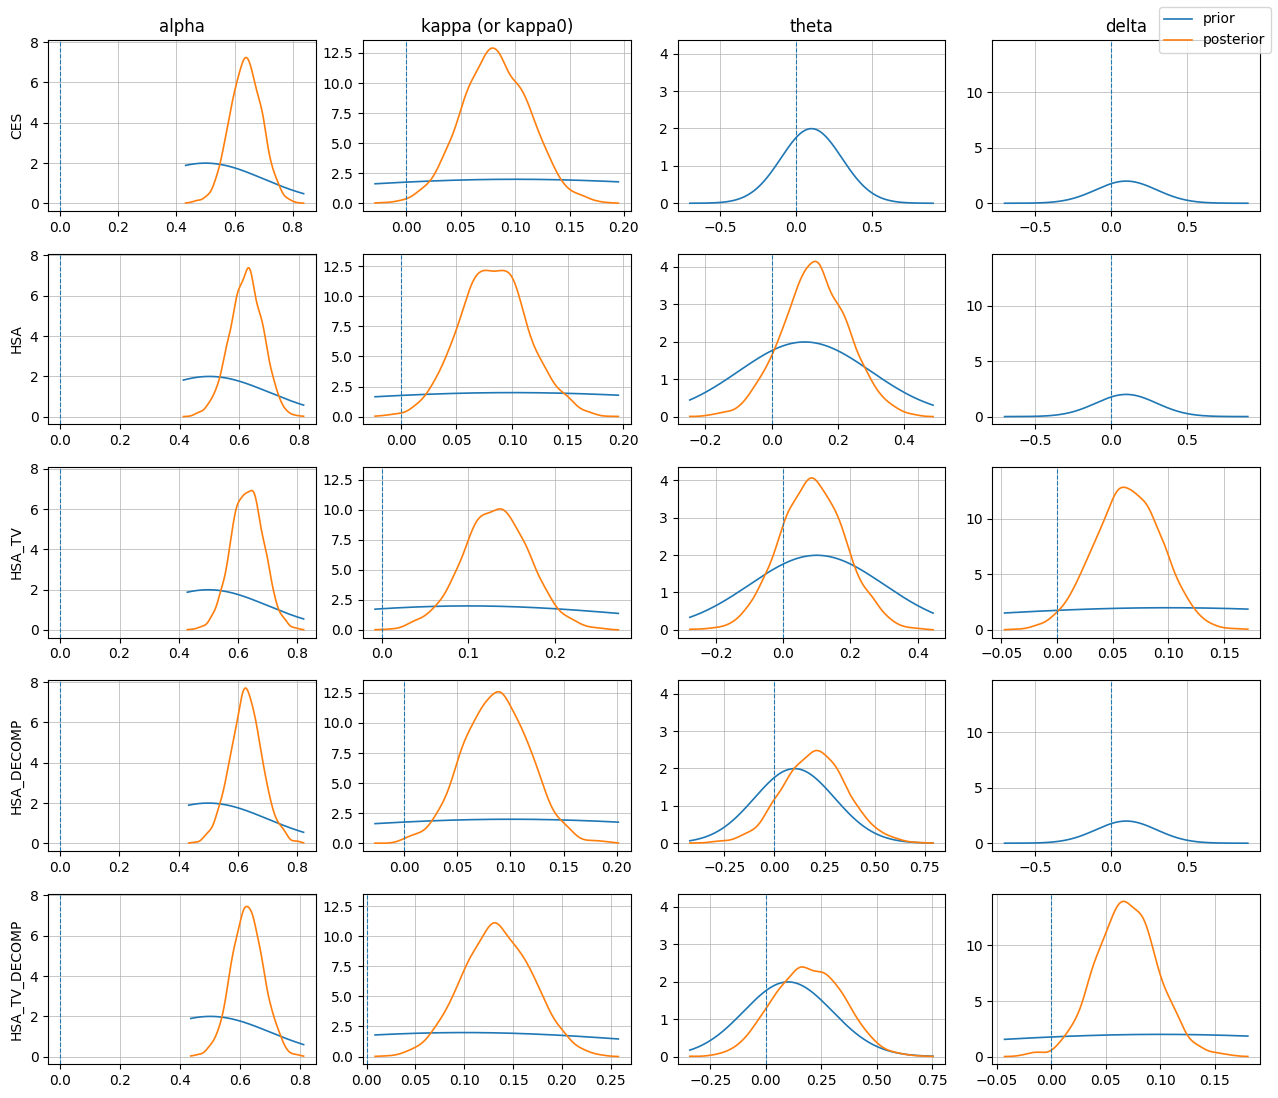

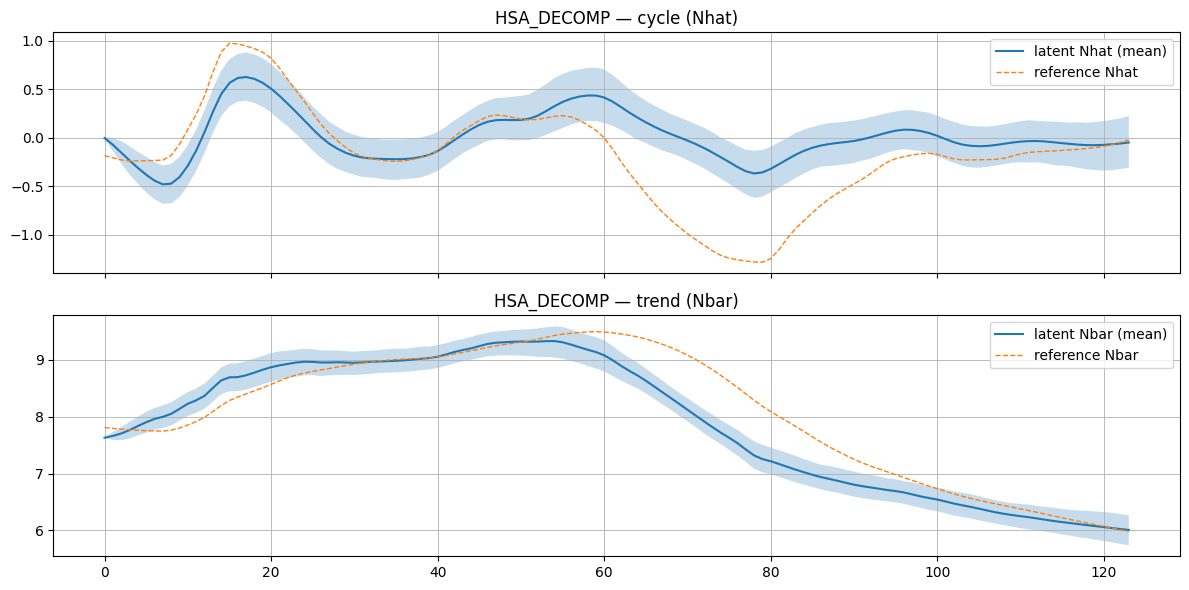

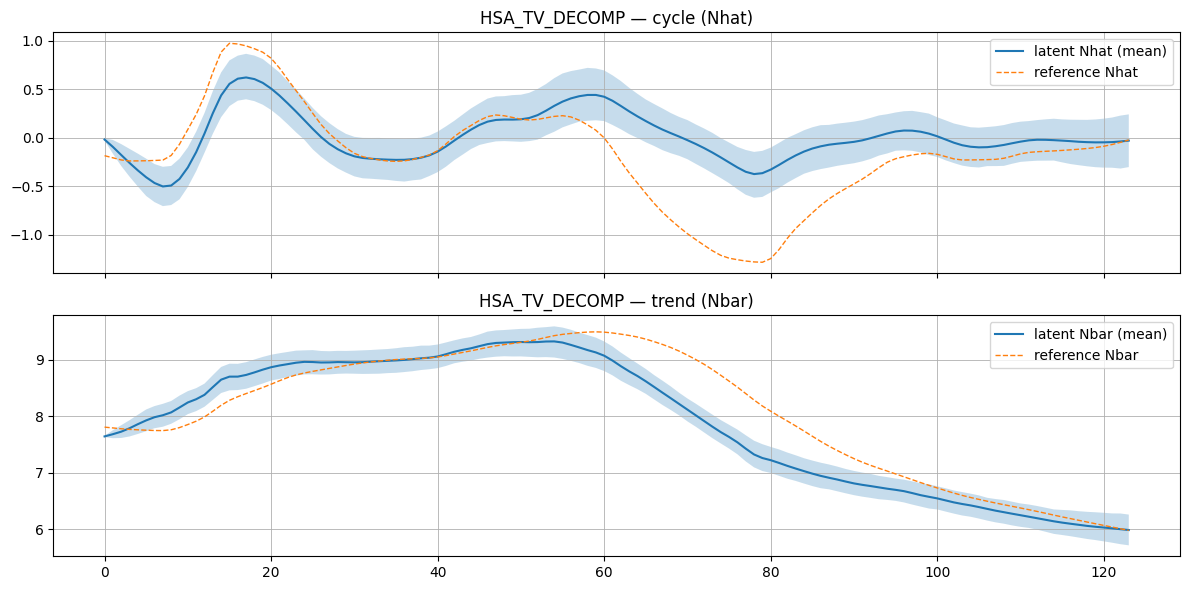

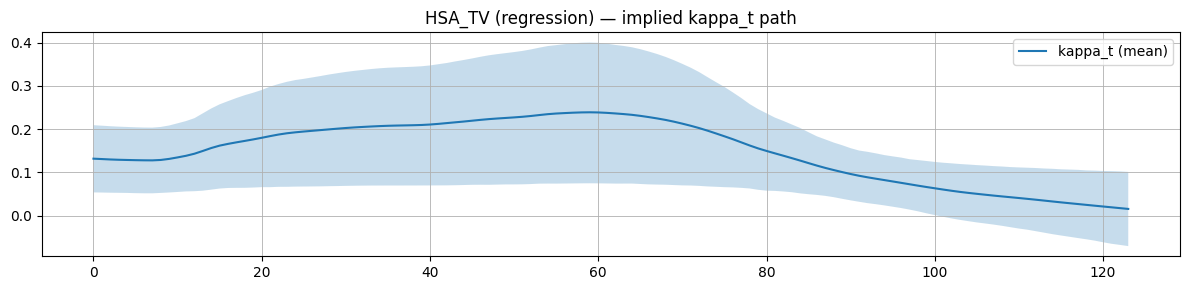

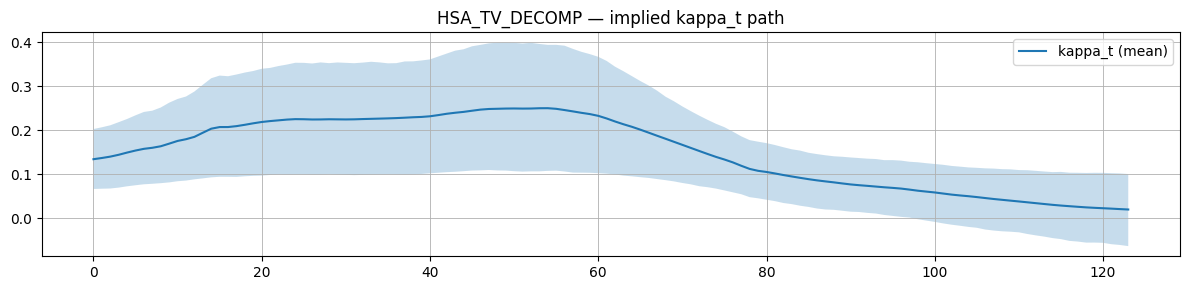

In [23]:
# data bundle for regression likelihoods
x_series = x_employment_gap
bundle_reg = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series)
bundle_hsa = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, Nhat=Nhat)
bundle_tv  = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, Nbar=Nbar, Nhat=Nhat)
bundle_ss  = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, N=N)
# --- Gibbs sampling ---
draws_ces = gibbs_ces(**bundle_reg, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_hsa = gibbs_hsa(**bundle_hsa, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_tv  = gibbs_hsa_tv(**bundle_tv, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_decomp = gibbs_hsa_decomp_ffbs(**bundle_ss, n_iter=N_ITER_SS, burn=BURN_SS, thin=THIN_SS, rng=rng, store_states=True)
draws_tv_decomp = gibbs_hsa_tv_decomp_ffbs(**bundle_ss, n_iter=N_ITER_SS, burn=BURN_SS, thin=THIN_SS, rng=rng, store_states=True)


# --- Marginal likelihoods (bridge sampling) ---
logml = {}
logml["CES"] = compute_log_marginal("CES", draws_ces, bundle_reg, rng)
logml["HSA"] = compute_log_marginal("HSA", draws_hsa, bundle_hsa, rng)
logml["HSA_TV"] = compute_log_marginal("HSA_TV", draws_tv, bundle_tv, rng)
logml["HSA_DECOMP"] = compute_log_marginal("HSA_DECOMP", draws_decomp, bundle_ss, rng)
logml["HSA_TV_DECOMP"] = compute_log_marginal("HSA_TV_DECOMP", draws_tv_decomp, bundle_ss, rng)

df = pd.DataFrame({
    "model": list(logml.keys()),
    "log_marginal_lik": list(logml.values()),
}).sort_values("log_marginal_lik", ascending=False).reset_index(drop=True)

# Bayes factors vs best model (in log space)
df["log_BF_vs_best"] = df["log_marginal_lik"] - df["log_marginal_lik"].iloc[0]

display(df)


# Build tables for this suite
draws_by_model = {
    "CES": draws_ces,
    "HSA": draws_hsa,
    "HSA_TV": draws_tv,
    "HSA_DECOMP": draws_decomp,
    "HSA_TV_DECOMP": draws_tv_decomp,
}

display(HTML("<h3>Coefficient summary (posterior mean + 95% CI)</h3>"))
coef_params = ["alpha","kappa","kappa0","delta","theta","n","r","p","rho_1","rho_2"]
coef_tab = coefficient_table(draws_by_model, coef_params, cred=0.95, digits=3)
display(coef_tab)

display(HTML("<h3>Savage–Dickey density ratio at 0 (BF_01 = posterior/prior)</h3>"))
sddr_df = sddr_table(draws_by_model, params=("kappa","kappa0","theta","delta","alpha"))
if len(sddr_df) > 0:
    display(sddr_df.sort_values(["param","model"]))
else:
    print("No SDDR parameters found in draws.")

display(HTML("<h3>Prior vs posterior density (coefficients)</h3>"))
prior_map = {
    "alpha": (alpha_mu, alpha_sd),
    "kappa": (kappa_mu, kappa_sd),     
    "theta": (theta_mu, theta_sd),
    "delta": (delta_mu, delta_sd),
}
plot_prior_posterior_grid(draws_by_model)
# Latent paths (only for decomposition models)
display(HTML("<h3>Latent paths (trend/cycle) for decomposition models</h3>"))
T = len(x_series)
time_index = np.arange(T)
plot_trend_cycle(draws_decomp, time_index, title="HSA_DECOMP", Nhat_ref=Nhat, Nbar_ref=Nbar, cred=0.95)
plot_trend_cycle(draws_tv_decomp, time_index, title="HSA_TV_DECOMP", Nhat_ref=Nhat, Nbar_ref=Nbar, cred=0.95)

# kappa_t paths for TV models
display(HTML("<h3>Implied kappa_t paths (TV models)</h3>"))
plot_kappa_t(draws_tv, time_index, x_series, title="HSA_TV (regression)", Nbar_series=Nbar, cred=0.95)
plot_kappa_t(draws_tv_decomp, time_index, x_series, title="HSA_TV_DECOMP", Nbar_series=None, cred=0.95)

,model,log_marginal_lik,log_BF_vs_best
0,HSA_DECOMP,-28.750553,0.000000
1,HSA_TV_DECOMP,-29.136893,-0.386340
2,HSA,-136.751435,-108.000882
3,CES,-136.780081,-108.029528
4,HSA_TV,-137.768292,-109.017738


,model,alpha,kappa,kappa0,delta,theta,n,r,p,rho_1,rho_2
0,CES,"0.652 [0.541, 0.764]","0.011 [-0.153, 0.181]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HSA,"0.633 [0.520, 0.746]","0.025 [-0.142, 0.190]",NaN,NaN,"0.130 [-0.072, 0.326]",NaN,NaN,NaN,NaN,NaN
2,HSA_TV,"0.637 [0.525, 0.751]",NaN,"0.023 [-0.150, 0.195]","0.015 [-0.147, 0.178]","0.124 [-0.074, 0.324]",NaN,NaN,NaN,NaN,NaN
3,HSA_DECOMP,"0.638 [0.529, 0.750]","0.026 [-0.139, 0.196]",NaN,NaN,"0.171 [-0.162, 0.481]","-0.013 [-0.024, -0.002]","0.937 [0.886, 0.981]","0.102 [0.100, 0.106]","1.779 [1.684, 1.863]","-0.879 [-0.962, -0.785]"
4,HSA_TV_DECOMP,"0.642 [0.527, 0.755]",NaN,"0.026 [-0.140, 0.198]","0.026 [-0.134, 0.187]","0.173 [-0.150, 0.507]","-0.013 [-0.024, -0.002]","0.937 [0.880, 0.983]","0.102 [0.100, 0.107]","1.779 [1.668, 1.867]","-0.879 [-0.966, -0.774]"


,model,param,SDDR_BF01_post_over_prior_at0,log_SDDR_BF01
1,CES,alpha,0.000000e+00,NaN
4,HSA,alpha,1.209122e-308,-709.006314
10,HSA_DECOMP,alpha,1.636028e-269,-618.903119
7,HSA_TV,alpha,7.274872e-279,-640.436815
13,HSA_TV_DECOMP,alpha,1.686296e-248,-570.518568
6,HSA_TV,delta,2.557168e+00,0.938900
12,HSA_TV_DECOMP,delta,2.631144e+00,0.967419
0,CES,kappa,2.596770e+00,0.954268
2,HSA,kappa,2.462261e+00,0.901080
8,HSA_DECOMP,kappa,2.348452e+00,0.853757


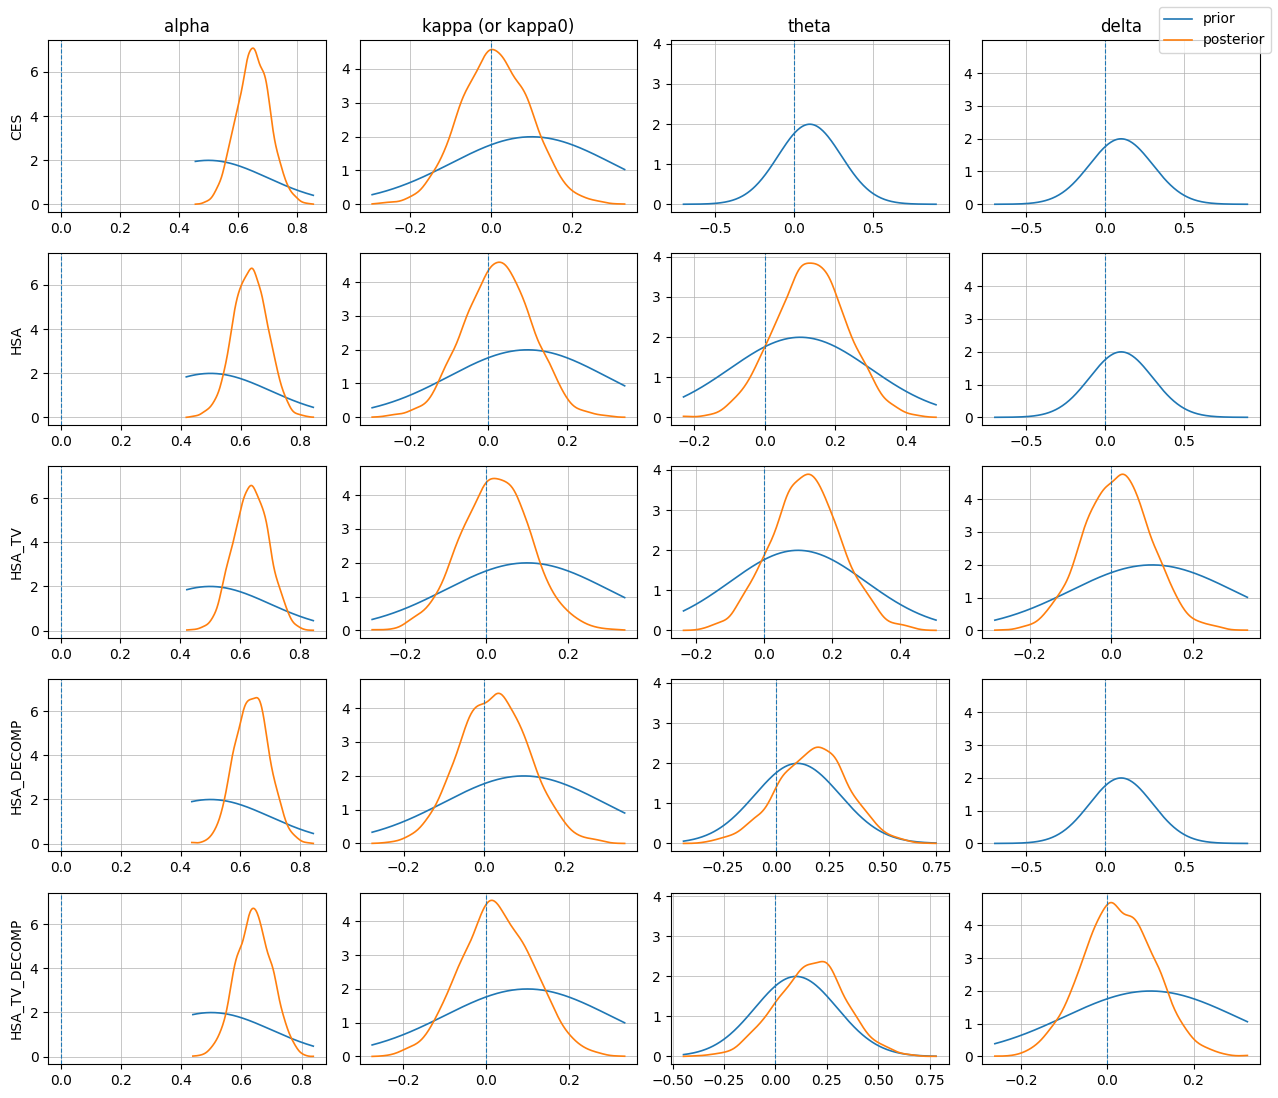

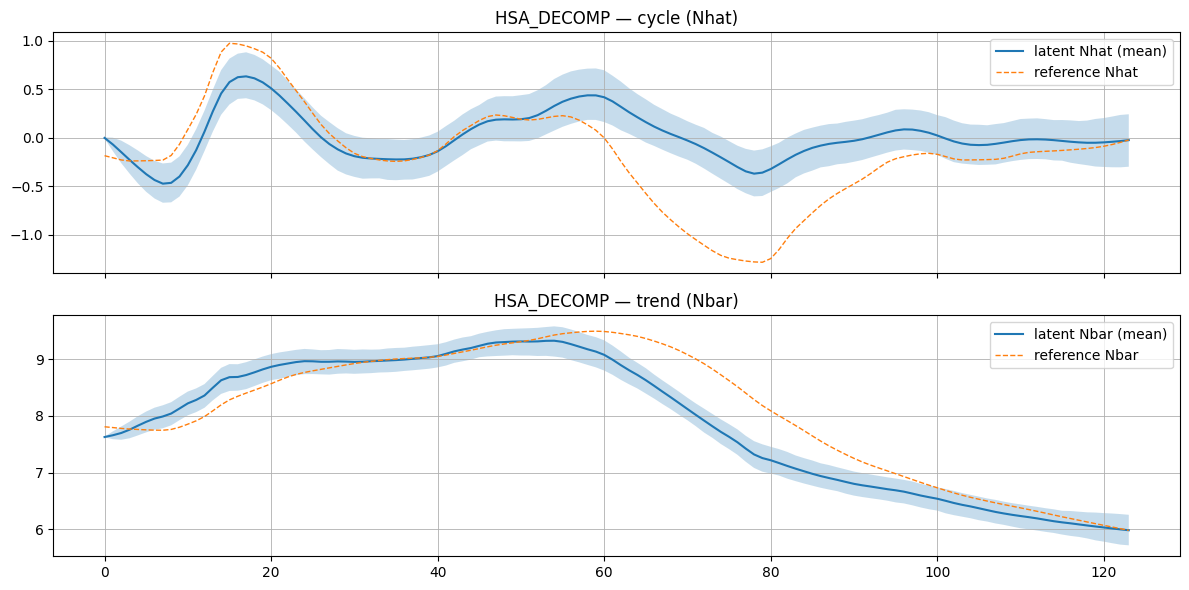

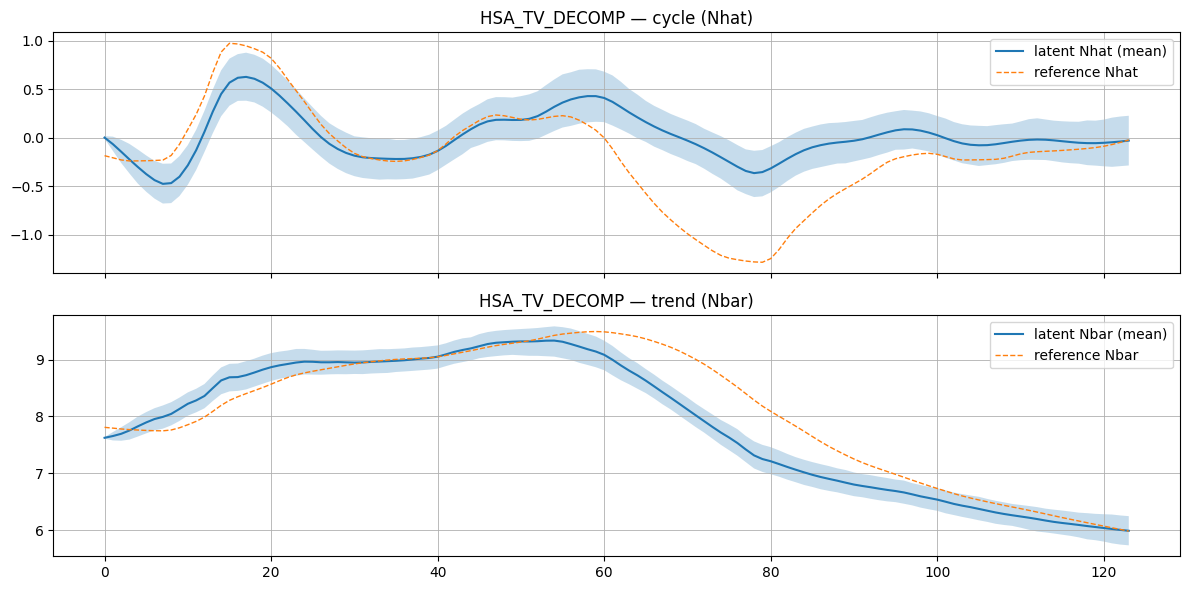

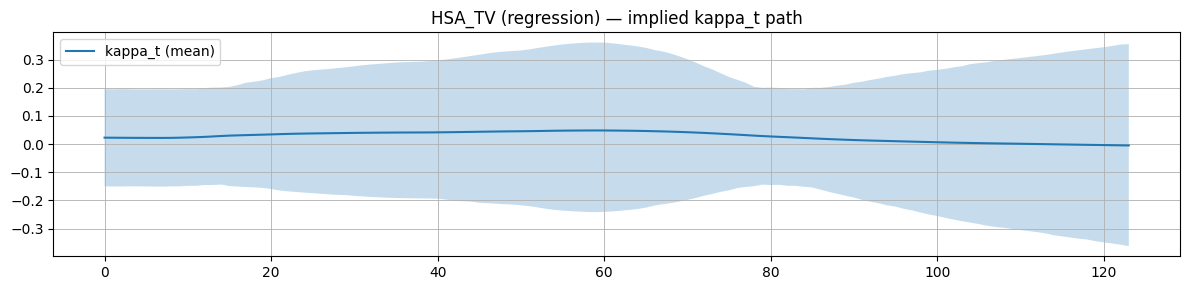

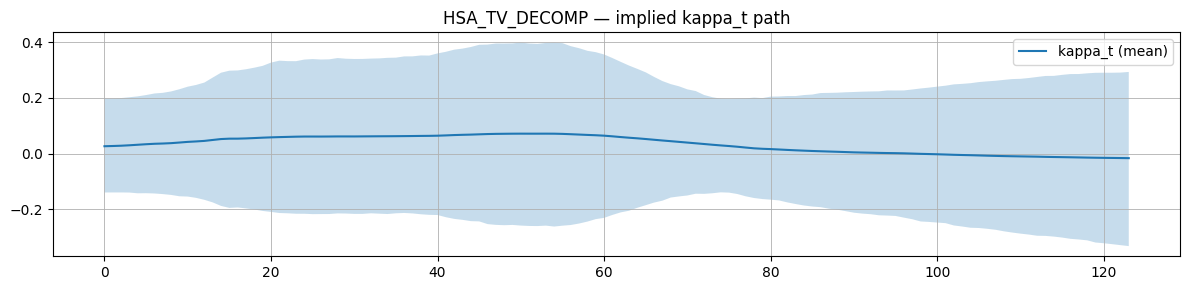

In [24]:
# data bundle for regression likelihoods
x_series = x_markup
bundle_reg = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series)
bundle_hsa = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, Nhat=Nhat)
bundle_tv  = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, Nbar=Nbar, Nhat=Nhat)
bundle_ss  = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, N=N)
# --- Gibbs sampling ---
draws_ces = gibbs_ces(**bundle_reg, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_hsa = gibbs_hsa(**bundle_hsa, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_tv  = gibbs_hsa_tv(**bundle_tv, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_decomp = gibbs_hsa_decomp_ffbs(**bundle_ss, n_iter=N_ITER_SS, burn=BURN_SS, thin=THIN_SS, rng=rng, store_states=True)
draws_tv_decomp = gibbs_hsa_tv_decomp_ffbs(**bundle_ss, n_iter=N_ITER_SS, burn=BURN_SS, thin=THIN_SS, rng=rng, store_states=True)


# --- Marginal likelihoods (bridge sampling) ---
logml = {}
logml["CES"] = compute_log_marginal("CES", draws_ces, bundle_reg, rng)
logml["HSA"] = compute_log_marginal("HSA", draws_hsa, bundle_hsa, rng)
logml["HSA_TV"] = compute_log_marginal("HSA_TV", draws_tv, bundle_tv, rng)
logml["HSA_DECOMP"] = compute_log_marginal("HSA_DECOMP", draws_decomp, bundle_ss, rng)
logml["HSA_TV_DECOMP"] = compute_log_marginal("HSA_TV_DECOMP", draws_tv_decomp, bundle_ss, rng)

df = pd.DataFrame({
    "model": list(logml.keys()),
    "log_marginal_lik": list(logml.values()),
}).sort_values("log_marginal_lik", ascending=False).reset_index(drop=True)

# Bayes factors vs best model (in log space)
df["log_BF_vs_best"] = df["log_marginal_lik"] - df["log_marginal_lik"].iloc[0]

display(df)


# Build tables for this suite
draws_by_model = {
    "CES": draws_ces,
    "HSA": draws_hsa,
    "HSA_TV": draws_tv,
    "HSA_DECOMP": draws_decomp,
    "HSA_TV_DECOMP": draws_tv_decomp,
}

display(HTML("<h3>Coefficient summary (posterior mean + 95% CI)</h3>"))
coef_params = ["alpha","kappa","kappa0","delta","theta","n","r","p","rho_1","rho_2"]
coef_tab = coefficient_table(draws_by_model, coef_params, cred=0.95, digits=3)
display(coef_tab)

display(HTML("<h3>Savage–Dickey density ratio at 0 (BF_01 = posterior/prior)</h3>"))
sddr_df = sddr_table(draws_by_model, params=("kappa","kappa0","theta","delta","alpha"))
if len(sddr_df) > 0:
    display(sddr_df.sort_values(["param","model"]))
else:
    print("No SDDR parameters found in draws.")

display(HTML("<h3>Prior vs posterior density (coefficients)</h3>"))
prior_map = {
    "alpha": (alpha_mu, alpha_sd),
    "kappa": (kappa_mu, kappa_sd),     
    "theta": (theta_mu, theta_sd),
    "delta": (delta_mu, delta_sd),
}
plot_prior_posterior_grid(draws_by_model)
# Latent paths (only for decomposition models)
display(HTML("<h3>Latent paths (trend/cycle) for decomposition models</h3>"))
T = len(x_series)
time_index = np.arange(T)
plot_trend_cycle(draws_decomp, time_index, title="HSA_DECOMP", Nhat_ref=Nhat, Nbar_ref=Nbar, cred=0.95)
plot_trend_cycle(draws_tv_decomp, time_index, title="HSA_TV_DECOMP", Nhat_ref=Nhat, Nbar_ref=Nbar, cred=0.95)

# kappa_t paths for TV models
display(HTML("<h3>Implied kappa_t paths (TV models)</h3>"))
plot_kappa_t(draws_tv, time_index, x_series, title="HSA_TV (regression)", Nbar_series=Nbar, cred=0.95)
plot_kappa_t(draws_tv_decomp, time_index, x_series, title="HSA_TV_DECOMP", Nbar_series=None, cred=0.95)

,model,log_marginal_lik,log_BF_vs_best
0,HSA_TV_DECOMP,-24.652955,0.000000
1,HSA_DECOMP,-26.429747,-1.776792
2,HSA_TV,-133.795735,-109.142780
3,HSA,-134.511279,-109.858324
4,CES,-134.955069,-110.302114


,model,alpha,kappa,kappa0,delta,theta,n,r,p,rho_1,rho_2
0,CES,"0.689 [0.577, 0.802]","0.091 [0.009, 0.169]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HSA,"0.677 [0.564, 0.791]","0.101 [0.022, 0.178]",NaN,NaN,"0.158 [-0.039, 0.345]",NaN,NaN,NaN,NaN,NaN
2,HSA_TV,"0.644 [0.527, 0.762]",NaN,"0.079 [0.001, 0.158]","-0.087 [-0.162, -0.008]","0.186 [-0.005, 0.381]",NaN,NaN,NaN,NaN,NaN
3,HSA_DECOMP,"0.683 [0.569, 0.797]","0.097 [0.023, 0.171]",NaN,NaN,"0.193 [-0.128, 0.491]","-0.013 [-0.025, -0.002]","0.937 [0.882, 0.982]","0.102 [0.100, 0.107]","1.780 [1.677, 1.865]","-0.879 [-0.965, -0.778]"
4,HSA_TV_DECOMP,"0.644 [0.532, 0.757]",NaN,"0.076 [-0.002, 0.154]","-0.094 [-0.171, -0.018]","0.177 [-0.140, 0.474]","-0.014 [-0.025, -0.002]","0.939 [0.886, 0.987]","0.102 [0.100, 0.107]","1.783 [1.681, 1.876]","-0.882 [-0.974, -0.785]"


,model,param,SDDR_BF01_post_over_prior_at0,log_SDDR_BF01
1,CES,alpha,0.000000e+00,NaN
4,HSA,alpha,0.000000e+00,NaN
10,HSA_DECOMP,alpha,3.990306e-296,-680.181320
7,HSA_TV,alpha,3.092215e-270,-620.569087
13,HSA_TV_DECOMP,alpha,2.861959e-267,-613.738714
6,HSA_TV,delta,6.086752e-01,-0.496470
12,HSA_TV_DECOMP,delta,3.437716e-01,-1.067778
0,CES,kappa,5.276820e-01,-0.639261
2,HSA,kappa,2.801262e-01,-1.272515
8,HSA_DECOMP,kappa,2.593252e-01,-1.349672


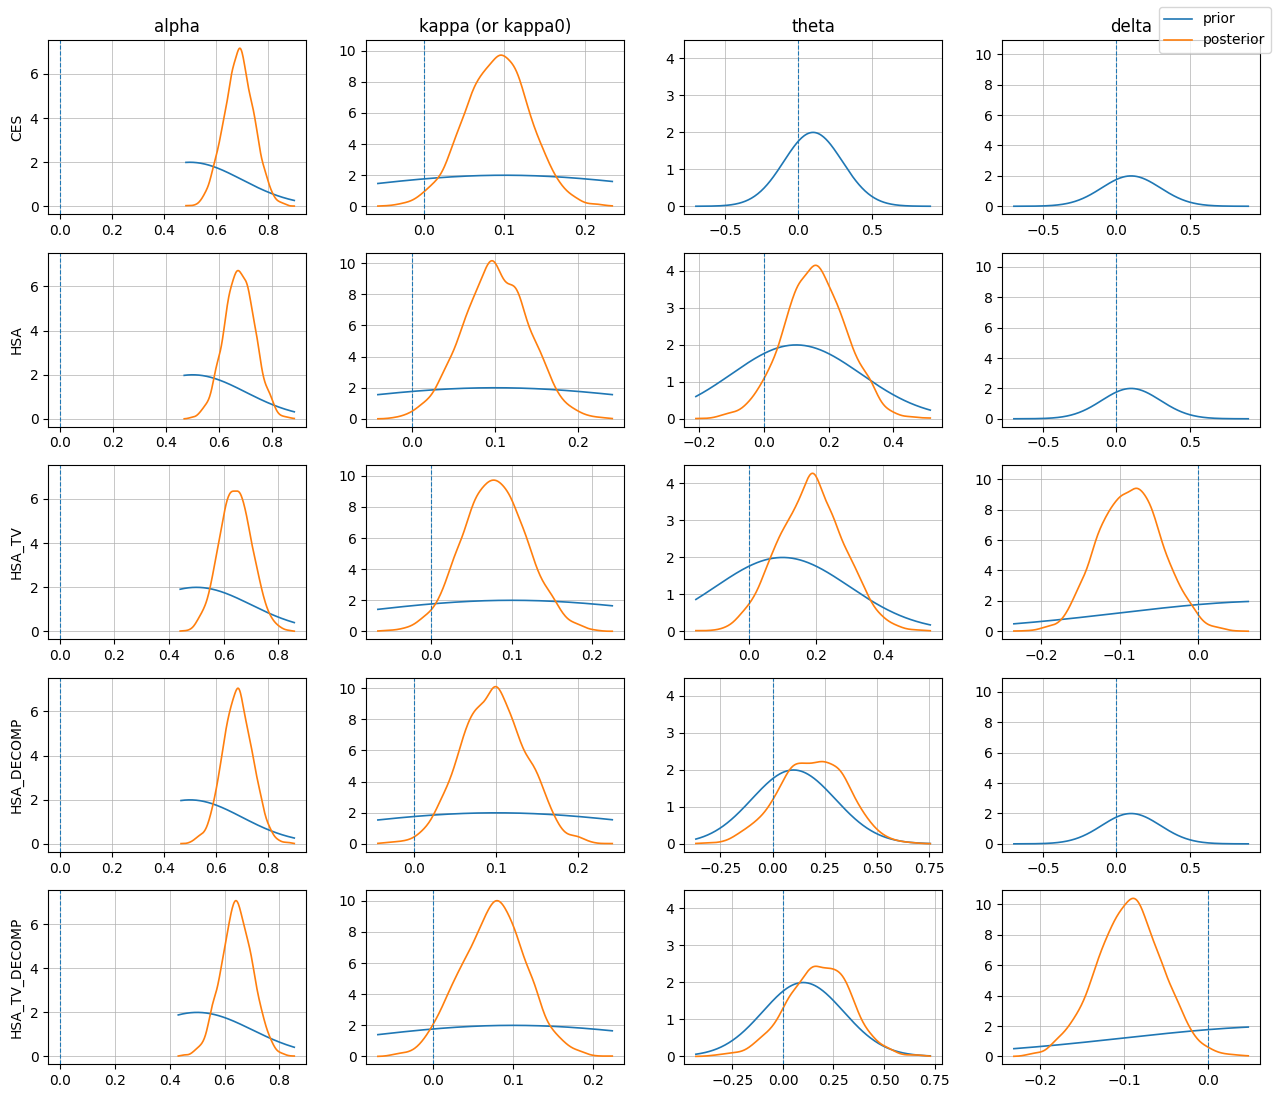

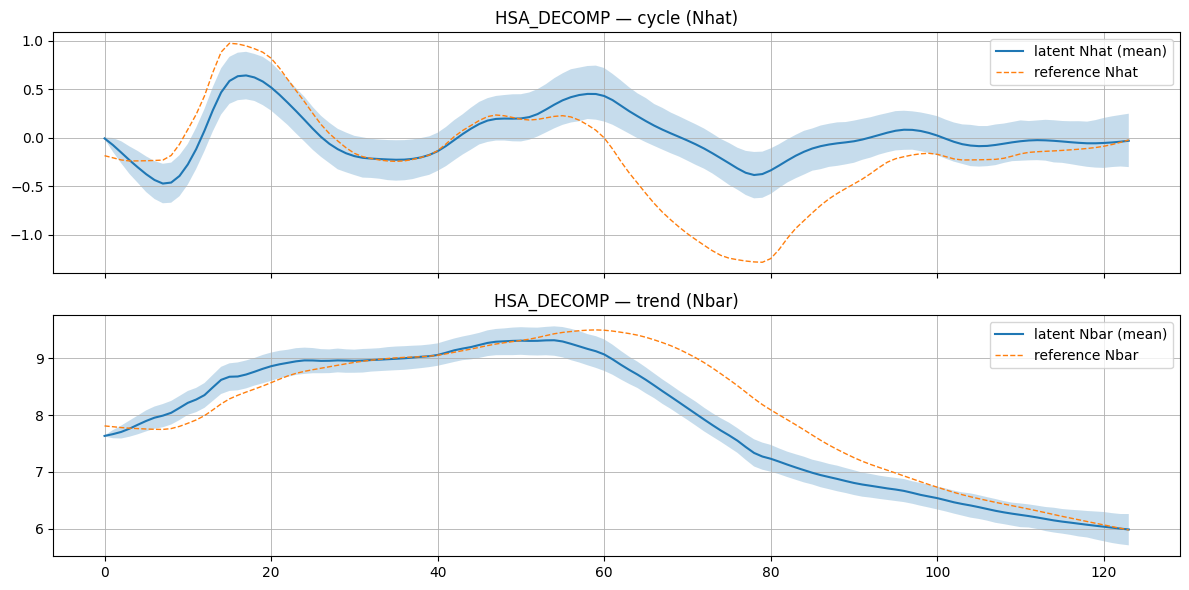

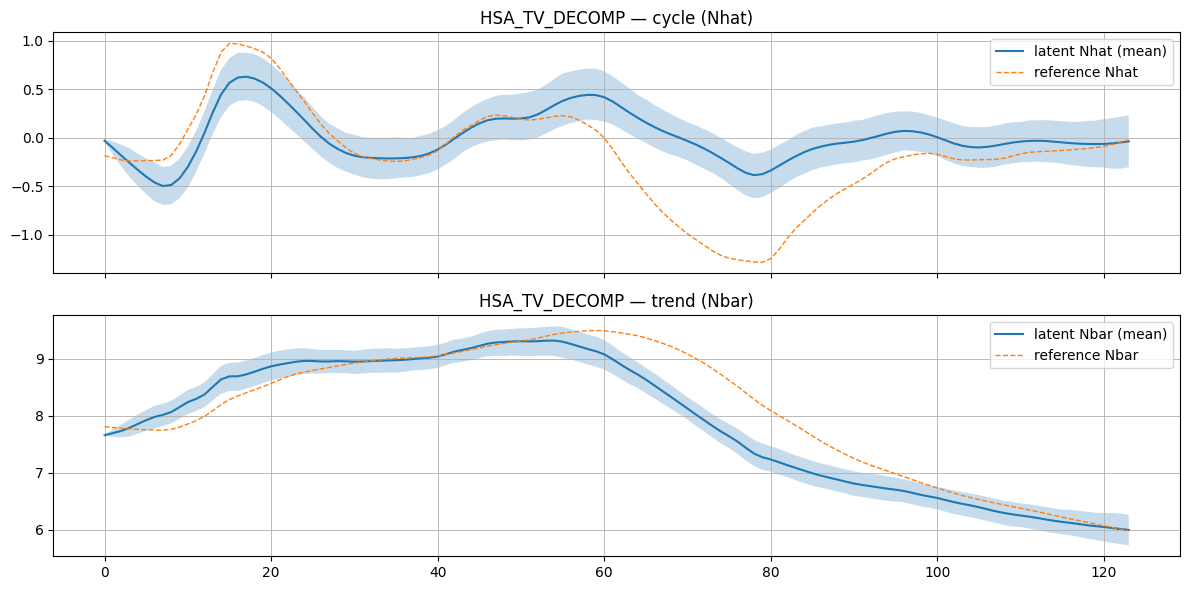

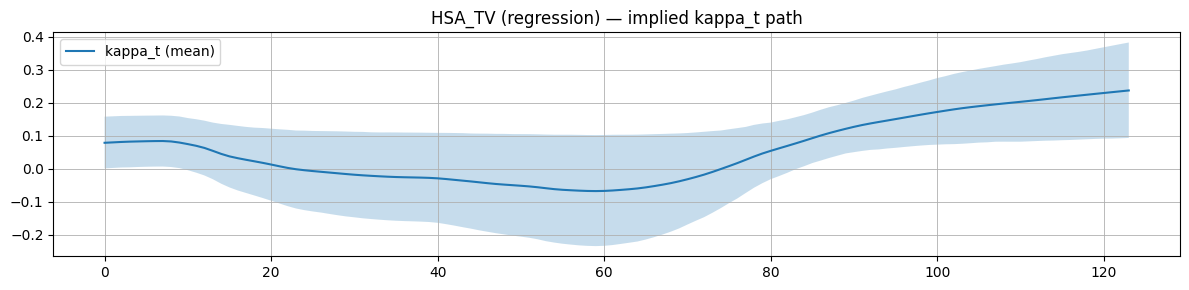

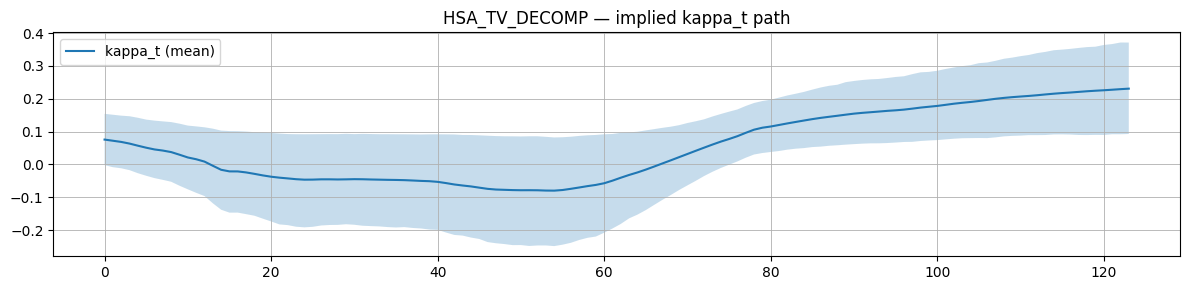

In [25]:
# data bundle for regression likelihoods
x_series = x_output_gap
bundle_reg = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series)
bundle_hsa = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, Nhat=Nhat)
bundle_tv  = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, Nbar=Nbar, Nhat=Nhat)
bundle_ss  = dict(pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_series, N=N)
# --- Gibbs sampling ---
draws_ces = gibbs_ces(**bundle_reg, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_hsa = gibbs_hsa(**bundle_hsa, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_tv  = gibbs_hsa_tv(**bundle_tv, n_iter=N_ITER_REG, burn=BURN_REG, thin=THIN_REG, rng=rng)
draws_decomp = gibbs_hsa_decomp_ffbs(**bundle_ss, n_iter=N_ITER_SS, burn=BURN_SS, thin=THIN_SS, rng=rng, store_states=True)
draws_tv_decomp = gibbs_hsa_tv_decomp_ffbs(**bundle_ss, n_iter=N_ITER_SS, burn=BURN_SS, thin=THIN_SS, rng=rng, store_states=True)


# --- Marginal likelihoods (bridge sampling) ---
logml = {}
logml["CES"] = compute_log_marginal("CES", draws_ces, bundle_reg, rng)
logml["HSA"] = compute_log_marginal("HSA", draws_hsa, bundle_hsa, rng)
logml["HSA_TV"] = compute_log_marginal("HSA_TV", draws_tv, bundle_tv, rng)
logml["HSA_DECOMP"] = compute_log_marginal("HSA_DECOMP", draws_decomp, bundle_ss, rng)
logml["HSA_TV_DECOMP"] = compute_log_marginal("HSA_TV_DECOMP", draws_tv_decomp, bundle_ss, rng)

df = pd.DataFrame({
    "model": list(logml.keys()),
    "log_marginal_lik": list(logml.values()),
}).sort_values("log_marginal_lik", ascending=False).reset_index(drop=True)

# Bayes factors vs best model (in log space)
df["log_BF_vs_best"] = df["log_marginal_lik"] - df["log_marginal_lik"].iloc[0]

display(df)


# Build tables for this suite
draws_by_model = {
    "CES": draws_ces,
    "HSA": draws_hsa,
    "HSA_TV": draws_tv,
    "HSA_DECOMP": draws_decomp,
    "HSA_TV_DECOMP": draws_tv_decomp,
}

display(HTML("<h3>Coefficient summary (posterior mean + 95% CI)</h3>"))
coef_params = ["alpha","kappa","kappa0","delta","theta","n","r","p","rho_1","rho_2"]
coef_tab = coefficient_table(draws_by_model, coef_params, cred=0.95, digits=3)
display(coef_tab)

display(HTML("<h3>Savage–Dickey density ratio at 0 (BF_01 = posterior/prior)</h3>"))
sddr_df = sddr_table(draws_by_model, params=("kappa","kappa0","theta","delta","alpha"))
if len(sddr_df) > 0:
    display(sddr_df.sort_values(["param","model"]))
else:
    print("No SDDR parameters found in draws.")

display(HTML("<h3>Prior vs posterior density (coefficients)</h3>"))
prior_map = {
    "alpha": (alpha_mu, alpha_sd),
    "kappa": (kappa_mu, kappa_sd),     
    "theta": (theta_mu, theta_sd),
    "delta": (delta_mu, delta_sd),
}
plot_prior_posterior_grid(draws_by_model)
# Latent paths (only for decomposition models)
display(HTML("<h3>Latent paths (trend/cycle) for decomposition models</h3>"))
T = len(x_series)
time_index = np.arange(T)
plot_trend_cycle(draws_decomp, time_index, title="HSA_DECOMP", Nhat_ref=Nhat, Nbar_ref=Nbar, cred=0.95)
plot_trend_cycle(draws_tv_decomp, time_index, title="HSA_TV_DECOMP", Nhat_ref=Nhat, Nbar_ref=Nbar, cred=0.95)

# kappa_t paths for TV models
display(HTML("<h3>Implied kappa_t paths (TV models)</h3>"))
plot_kappa_t(draws_tv, time_index, x_series, title="HSA_TV (regression)", Nbar_series=Nbar, cred=0.95)
plot_kappa_t(draws_tv_decomp, time_index, x_series, title="HSA_TV_DECOMP", Nbar_series=None, cred=0.95)